## 4.1 Fourier Optics Examples in python

###  Example 1 : difference between Fast Fourier Transform (FFT) and Discrete Fourier Transform (DFT)

#### DFT vs FFT: A Practical Comparison

This notebook compares the **Discrete Fourier Transform (DFT)** and the **Fast Fourier Transform (FFT)**.  
Both produce identical numerical results, but their computational efficiency differs dramatically.

##### Theory

For a sequence $g[n]$ of length $N$, the DFT is defined as  

$$
G[k] = \sum_{n=0}^{N-1} g[n] \, e^{-i 2\pi k n / N}, \qquad k = 0,\dots,N-1
$$

A direct implementation uses two nested loops, requiring $O(N^2)$ operations.  
The FFT is a family of algorithms that compute the **same** DFT in $O(N \log N)$ operations by exploiting symmetries and periodicities of the complex exponentials.

For large $N$ (e.g., $N=1064$), the difference in speed is enormous – the FFT completes in milliseconds, while a manual DFT may take minutes or hours.

##### What this code does

1. **Creates a shifted input signal**  
   The original Gaussian $g(x) = \exp[-(x/w_0)^2]$ (with $w_0 = 0.2$) is circularly shifted by $N/2$ using two manual loops. This shift is kept for illustration; the comparison works for any input.

2. **Implements a manual DFT** (double loop) – intentionally slow, for educational purposes.

3. **Computes the FFT** using `np.fft.fft` – fast, production‑ready.

4. **Compares execution times** with Python’s `time` module, showing the huge speed advantage of the FFT.

5. **Verifies numerical equivalence** – the two outputs match up to floating‑point precision.

6. **Plots magnitude and phase** of both transforms, confirming they are identical.

##### Why this is helpful

- **Understanding the cost of a naive DFT** – you will see that an $O(N^2)$ algorithm becomes unusable for realistic data sizes.
- **Appreciating why libraries use FFT** – in Fourier optics, images are often $1024 \times 1024$ or larger; an FFT is essential.
- **Recognising that the FFT is not an approximation** – it is an exact re‑implementation of the DFT.
- **Learning to use timing as a tool** for comparing algorithm performance.

For any real Fourier optics simulation, always use `numpy.fft` (or `scipy.fft`). The manual DFT shown here is purely for illustration.

In [119]:
import numpy as np
import matplotlib.pyplot as plt
import time


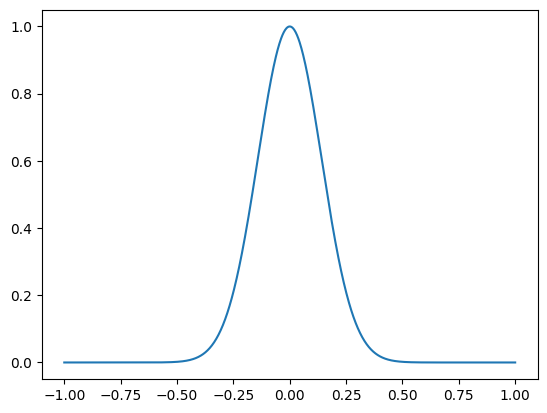

In [120]:
N = 1024
x0 = np.linspace(-1, 1, N)
delta = x0[1] - x0[0]
w0 = 2e-1
gx = lambda x : np.exp(-(x / w0)**2)
gx = gx(x0)
plt.plot(x0, gx)


In [121]:
np2 = [x for x in range(0, int(N))]

In [122]:
gxp = []

for i in range(0, int(N/2)):
    # print(int((i + N/2)))
    gxp.append(gx[int((i + N/2))])

for i in range(0, int(N/2)):
    # print(int((i)))
    gxp.append(gx[int(i)])


In [123]:
len(gxp) == len(gx) == N

True

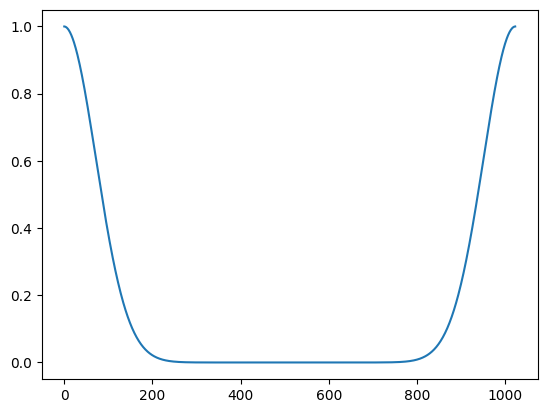

In [124]:
plt.plot(np2, gxp)

In [125]:
Gm = np.zeros(N, dtype=complex)
start_t = time.time()
for k in range(N):                  
    s = 0 + 0j
    for n in range(N):              
        s += gxp[n] * np.exp(-2j * np.pi * k * n / N)
    Gm[k] = s

end_t = time.time()
time_manual = end_t - start_t
print(f"Manual DFT completed in {time_manual:.2f} seconds")

Manual DFT completed in 2.06 seconds


Starting NumPy FFT...
NumPy FFT completed in 0.000000 seconds
Time difference between manual DFT and FFT: 2.064695119857788 seconds
Max difference between manual DFT and FFT: 5.47e-11


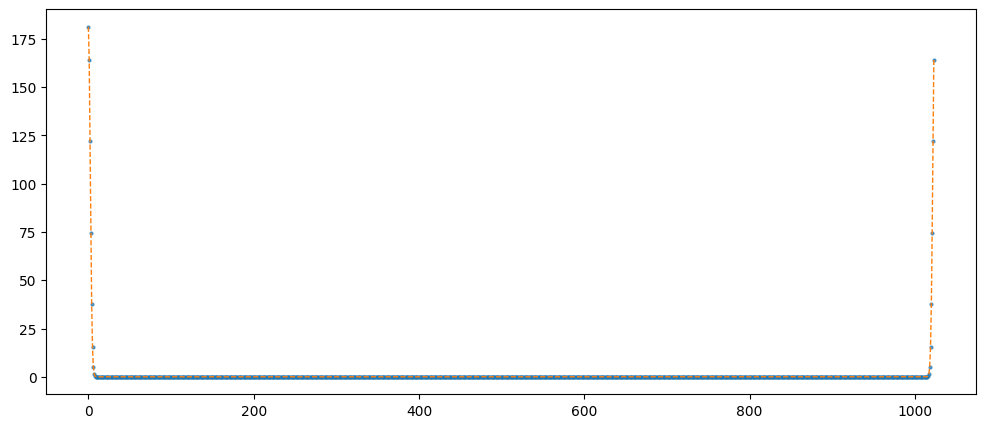

C:\Users\MOBIT\AppData\Local\Temp\ipykernel_13632\3007832109.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


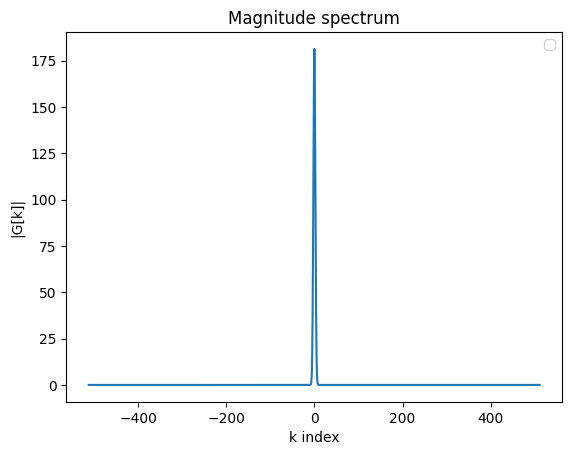

In [126]:
# -------------------  FFT  -------------------

print("Starting NumPy FFT...")
start_fft = time.time()
G_fft = np.fft.fft(gxp)          # FFT of the same shifted signal


end_fft = time.time()
time_fft = end_fft - start_fft
print(f"NumPy FFT completed in {time_fft:.6f} seconds")

# difference of the times
print(f"Time difference between manual DFT and FFT: {time_manual - time_fft} seconds")

# difference of the values
diff = np.max(np.abs(Gm - G_fft))
print(f"Max difference between manual DFT and FFT: {diff:.2e}")

# ------------------- Plot comparison -------------------
plt.figure(3, figsize=(12, 5))

plt.plot(np.abs(Gm), 'o', label='Manual DFT', markersize=2, alpha=0.7)
plt.plot(np.abs(G_fft), '--', label='NumPy FFT', linewidth=1)
plt.show()
plt.title('Magnitude spectrum')
plt.xlabel('k index')
plt.ylabel('|G[k]|')
plt.legend()
Gm_shifted = np.concatenate((Gm[N//2:], Gm[:N//2]))
k_shifted = np.arange(-N//2, N//2)
plt.plot(k_shifted, np.abs(Gm_shifted))
plt.show()


In [127]:
# <!-- Starting NumPy FFT...
# NumPy FFT completed in 0.000000 seconds
# Time difference between manual DFT and FFT: 1.4666252136230469
# Max difference between manual DFT and FFT: 4.67e-11 -->
# -------------------------------------------------------
# Starting NumPy FFT...
# NumPy FFT completed in 0.002990 seconds
# Time difference between manual DFT and FFT: 88.73701930046082 seconds
# Max difference between manual DFT and FFT: 1.98e-09

##  FFT -- Examples

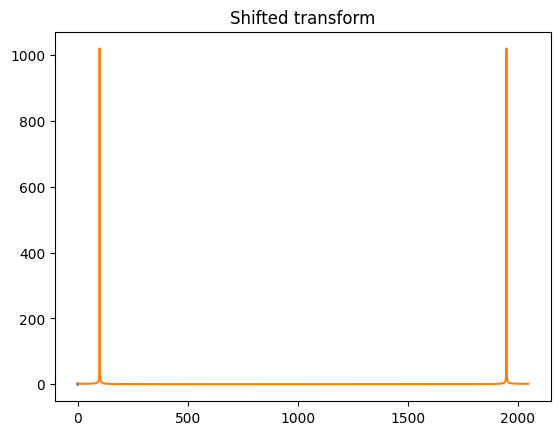

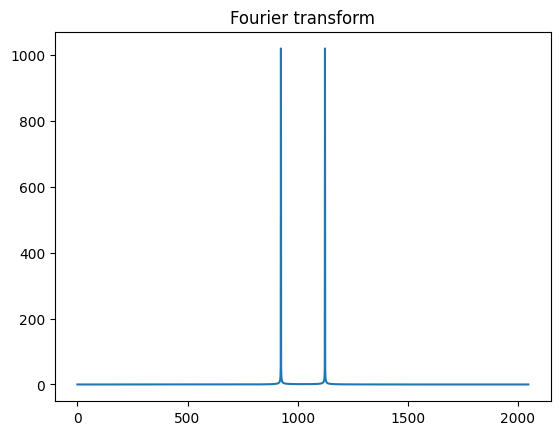

c:\Users\MOBIT\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\MOBIT\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


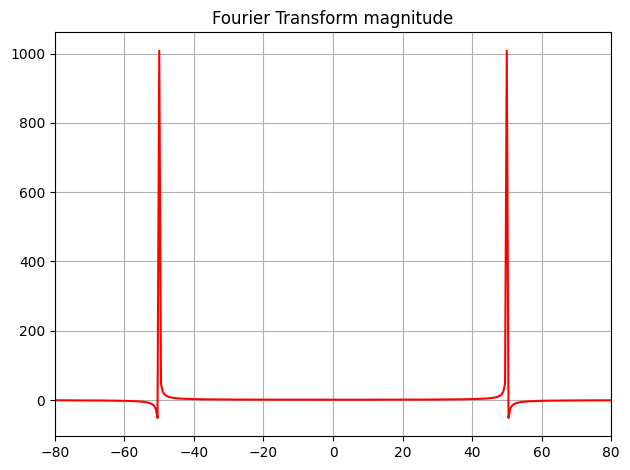

In [128]:
N = 2048
x_min, x_max = -1, 1
x = np.linspace(-1, 1, N)
dx = x[1] - x[0] # delta 
f = 50
s = np.cos(2*np.pi*f*x) # function
plt.plot(x, s)
S = np.fft.fft(s) # Fourier transform
plt.plot(np.abs(S))
plt.title("Shifted transform")
plt.show()

S = np.fft.fftshift(S) # Fourier transform shift
plt.plot(np.abs(S))
plt.title("Fourier transform")
plt.show()


freq = np.fft.fftfreq(N, d=dx)        # Fourier transform in frequency domain
freq_centered = np.fft.fftshift(freq)  # Shift fourier frequency

# Plotting


# Frequency domain (magnitude)
plt.plot(freq_centered, S, 'r-')
plt.title('Fourier Transform magnitude')
plt.grid(True)
plt.xlim(-80, 80)

plt.tight_layout()
plt.show()

### Example 2 : A wave with two Sin functions"

In [129]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [130]:
N = 2048
x_min, x_max = -0.25, 0.25
x = np.linspace(x_min,x_max, N)
dx = x[1] - x[0] # delta 
f1 = 10
f2 = 20
a1 = 1
a2 = 0.5

s = a1*np.sin(2*np.pi*f1*x) + a2*np.sin(2*np.pi*f2*x) # function


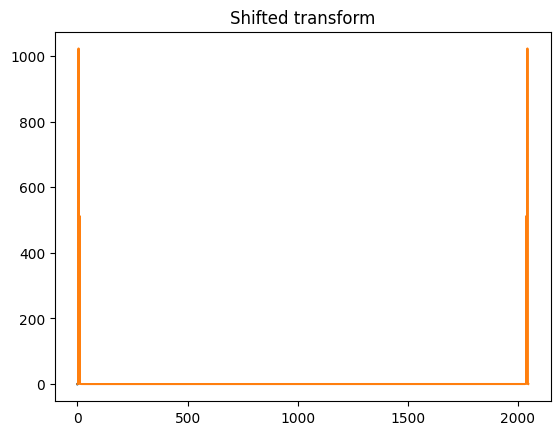

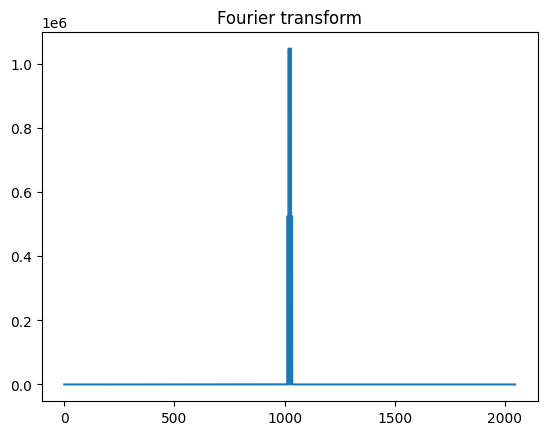

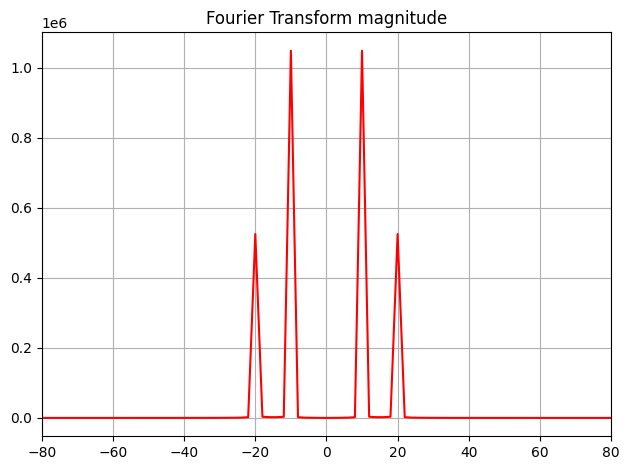

In [131]:

plt.plot(x, s)
S = np.fft.fft(s) # Fourier transform
plt.plot(np.abs(S))
plt.title("Shifted transform")
plt.show()

S = np.fft.fftshift(S) *N/2# Fourier transform shift
plt.plot(np.abs(S))
plt.title("Fourier transform")
plt.show()


freq = np.fft.fftfreq(N, d=dx)        # Fourier transform in frequency domain
freq_centered = np.fft.fftshift(freq)  # Shift fourier frequency

# Plotting


# Frequency domain (magnitude)
plt.plot(freq_centered, np.abs(S), 'r-')
plt.title('Fourier Transform magnitude')
plt.grid(True)
plt.xlim(-80, 80)

plt.tight_layout()
plt.show()

### Example 3 :  A noisy wave example

In [132]:
import numpy as np
import matplotlib.pyplot as plt
import time

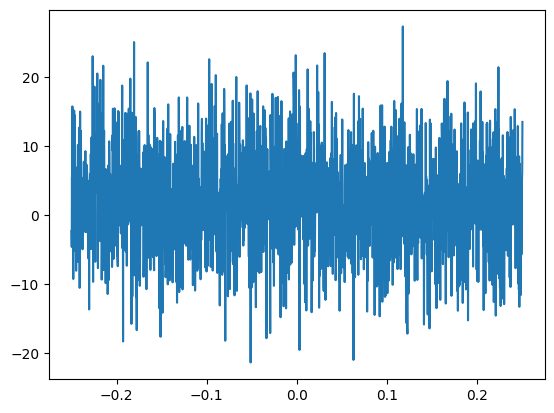

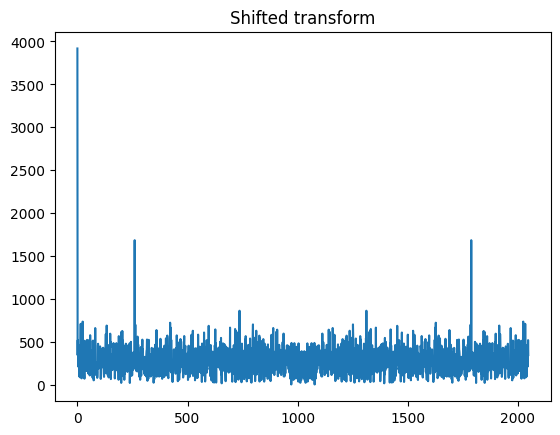

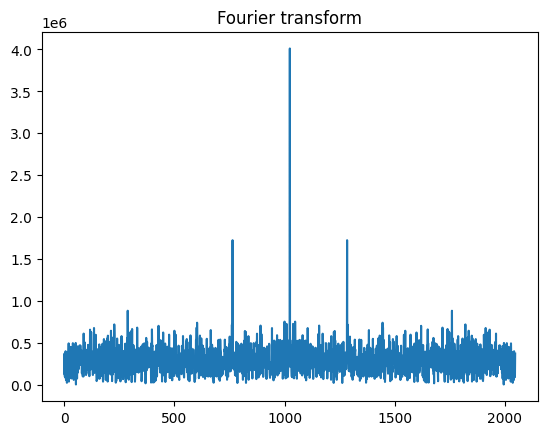

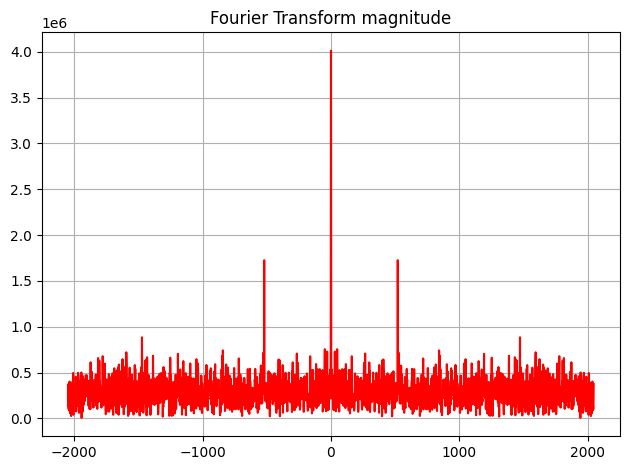

In [133]:
N = 2048
x_min, x_max = -0.25, 0.25
x = np.linspace(x_min,x_max, N)
dx = x[1] - x[0] # delta 
f1 = 1050
f2 = 520
f3 = 851
a1 = 0.5
a2 = 1.5
a3 = 0.3

s = a1*np.cos(2*np.pi*f1*x) + a2*np.cos(2*np.pi*f2*x) + a3*np.cos(2*np.pi*f3*x) + 2 # function
noise = np.random.randn(len(x)) * 7   
s = s + noise
plt.plot(x, s)
plt.show()

S = np.fft.fft(s) # Fourier transform
plt.plot(np.abs(S))
plt.title("Shifted transform")
plt.show()

S = np.fft.fftshift(S) *N/2# Fourier transform shift
plt.plot(np.abs(S))
plt.title("Fourier transform")
plt.show()


freq = np.fft.fftfreq(N, d=dx)        # Fourier transform in frequency domain
freq_centered = np.fft.fftshift(freq)  # Shift fourier frequency

# Plotting


# Frequency domain (magnitude)
plt.plot(freq_centered, np.abs(S), 'r-')
plt.title('Fourier Transform magnitude')
plt.grid(True)


plt.tight_layout()
plt.show()

### Example 4 : Fourier Transform of the Slits (Fraunhofer Diffraction)

##### Fourier Optics: Fraunhofer Diffraction from Apertures

This notebook simulates the far‑field (Fraunhofer) diffraction pattern of three common apertures – square, slit, and circular – using the 2D Fast Fourier Transform (FFT). According to scalar diffraction theory, the diffracted field in the far zone is proportional to the Fourier transform of the aperture transmission function.

##### Theory

For a monochromatic plane wave normally incident on an aperture with transmission function $t(x,y)$, the complex amplitude in the far field (Fraunhofer regime) is  

$$
U(u,v) \propto \iint_{-\infty}^{\infty} t(x,y) \, e^{-i2\pi(ux+vy)} \, dx\,dy
$$

where $u = x'/(\lambda z)$, $v = y'/(\lambda z)$ are spatial frequencies (in cycles per unit length). Thus the intensity pattern is essentially $| \mathcal{F}\{t\}|^2$.

In this code we numerically compute $\mathcal{F}\{t\}$ using `np.fft.fft2`, apply `fftshift` to centre the zero frequency, and plot the logarithm of the magnitude for better visibility.

##### What the code does

1. **Define coordinate grids**  
   $x \in [-1,1]$ (1024 points) and $y \in [-1,1]$ (512 points). A 2D meshgrid is created.

2. **Generate three aperture masks**  
   - **Square**: $|x| < 0.01$ and $|y| < 0.01$ (width 0.02).  
   - **Slit**: $0 < x < 0.01$ and $|y| < 0.8$ (horizontal slit).  
   - **Circular**: $r = \sqrt{x^2+y^2} < 0.03$.  

   All masks are binary: 1 inside the aperture, 0 outside.

3. **Compute the Fourier transform**  
   `np.fft.fft2` performs the 2D DFT. After shifting with `np.fft.fftshift`, the zero frequency is at the centre of the array.  
   Frequency axes (in $\text{m}^{-1}$) are obtained via `np.fft.fftfreq`.

4. **Plot the diffraction patterns**  
   The magnitude $|\mathcal{F}\{t\}|$ is displayed on a logarithmic scale (`np.log(1+|...|)`) to enhance weak features.  
   The three patterns illustrate well‑known results:  
   - Square aperture → 2D sinc function $\text{sinc}(u)\text{sinc}(v)$.  
   - Slit → 1D sinc in $x$‑direction, unchanged in $y$.  
   - Circular aperture → Airy disk $\left(2J_1(\pi r_0 \rho)/(\pi r_0 \rho)\right)^2$, where $\rho = \sqrt{u^2+v^2}$.

##### Why this is helpful

- **Direct application of the convolution theorem** – the FFT replaces Fresnel or Fraunhofer integrals.
- **Fast and flexible** – you can easily change aperture shapes or illumination conditions.
- **Visualisation of classic diffraction patterns** – connecting theory (sinc, Airy) to numerical simulation.
- **Preparation for more advanced topics** – e.g., grating diffraction, Fourier filtering, or optical system modelling.

For any real optical simulation, always use `numpy.fft.fft2` (or `scipy.fft`). The code above provides a complete, ready‑to‑use framework for simulating Fraunhofer diffraction from arbitrary apertures.

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import time

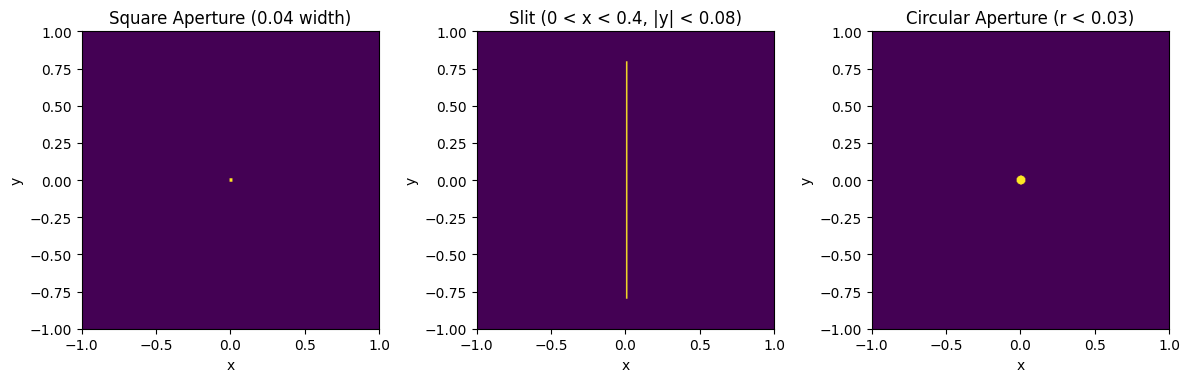

In [135]:
Nx = 1024
Ny = 512
x0 = np.linspace(-1, 1, Nx)
y0 = np.linspace(-1, 1, Ny)
X, Y = np.meshgrid(x0, y0)

#### converting coordinates into polar in case of circular aperture
def car2pol(X, Y):
    r = np.sqrt(X**2 + Y**2)   
    th = np.arctan2(Y, X)    
    return r, th
r, th = car2pol(X,Y)


def square_aperture(X, Y, half_width=0.01):
    condition = (np.abs(X) < half_width) & (np.abs(Y) < half_width)
    return np.where(condition, 1, 0)

def slit(X, Y, width=0.01):
    condition = (0 < X) & (X < width) & (np.abs(Y) < 0.8)
    return np.where(condition, 1, 0)

def circular(r, th):
    condition = r < 0.03
    return np.where(condition, 1, 0)

# --- Generate the apertures ---
square_mask = square_aperture(X, Y)
slit_mask = slit(X, Y)
circular_mask = circular(r, th)

# --- Plotting in a row of subplots ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Common imshow parameters
imshow_kw = dict(cmap='viridis', origin='lower', extent=[-1, 1, -1, 1])

# Square aperture
im0 = axes[0].imshow(square_mask, **imshow_kw)
axes[0].set_title('Square Aperture (0.04 width)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# Slit aperture
im1 = axes[1].imshow(slit_mask, **imshow_kw)
axes[1].set_title('Slit (0 < x < 0.4, |y| < 0.08)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

# Circular aperture
im2 = axes[2].imshow(circular_mask, **imshow_kw)
axes[2].set_title('Circular Aperture (r < 0.03)')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')



plt.tight_layout()
plt.show()

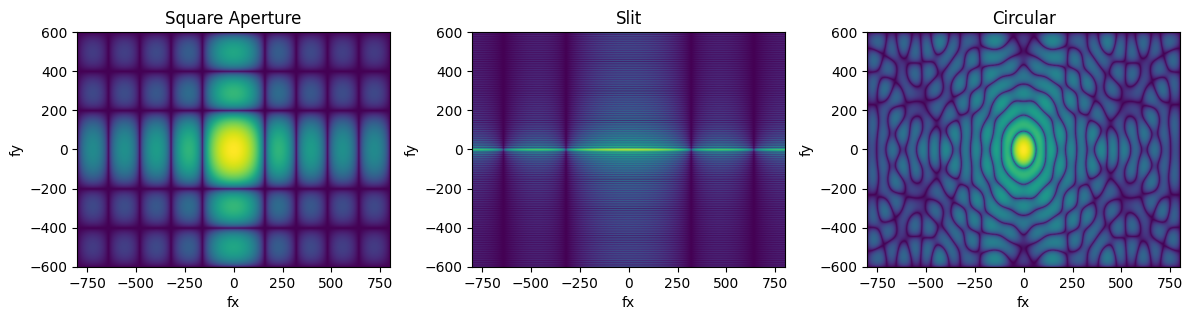

In [136]:
# Fourier transform of the square aperture
square_fft = np.fft.fftshift(np.fft.fft2(square_mask))
# Fourier transform of the single slit
slit_fft = np.fft.fftshift(np.fft.fft2(slit_mask))
# Fourier transform of the circular aperture
circular_fft = np.fft.fftshift(np.fft.fft2(circular_mask))



# Frequency axes (1D)
freq_x = np.fft.fftshift(np.fft.fftfreq(Nx, d=(x0[1]-x0[0])))   
freq_y = np.fft.fftshift(np.fft.fftfreq(Ny, d=(y0[1]-y0[0])))
# 2D frequency grid
FX, FY = np.meshgrid(freq_x, freq_y)

# --- Plotting in a row of subplots ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Common imshow parameters
imshow_kw = dict(cmap='viridis', origin='lower', extent=[-1, 1, -1, 1])

# Square aperture
im0 = axes[0].imshow(np.log(1 + np.abs(square_fft)), cmap='viridis', 
           extent=[-800, 800,-600, 600])
axes[0].set_title('Square Aperture')
axes[0].set_xlabel('fx')
axes[0].set_ylabel('fy')

# Slit aperture
im1 = axes[1].imshow(np.log(1 + np.abs(slit_fft)), cmap='viridis', 
           extent=[-800, 800,-600, 600])
axes[1].set_title('Slit')
axes[1].set_xlabel('fx')
axes[1].set_ylabel('fy')

# Circular aperture
im2 = axes[2].imshow(np.log(1 + np.abs(circular_fft)), cmap='viridis', 
           extent=[-800, 800,-600, 600])
axes[2].set_title('Circular')
axes[2].set_xlabel('fx')
axes[2].set_ylabel('fy')



plt.tight_layout()
plt.show()


### Example 5: Fourier Of The Fourier!!

In [137]:
import numpy as np
import matplotlib.pyplot as plt
import time
from PIL import Image

In [138]:
image_path = "Joseph_Fourier.jpg"  # define the path of the image
img = Image.open(image_path).convert('L') # open the image

img_array = np.array(img, dtype=float) # Using numpy and converting image to an array with the float type for better result


In [139]:

S = np.fft.fftshift(np.fft.fft2(img_array))

# Compute frequency
F = np.fft.fftshift(np.fft.fft2(img_array))
log_magnitude = np.log(np.abs(F))

# Create frequency axes 
rows, cols = img_array.shape
fx = np.fft.fftshift(np.fft.fftfreq(cols, d=1))   
fy = np.fft.fftshift(np.fft.fftfreq(rows, d=1))



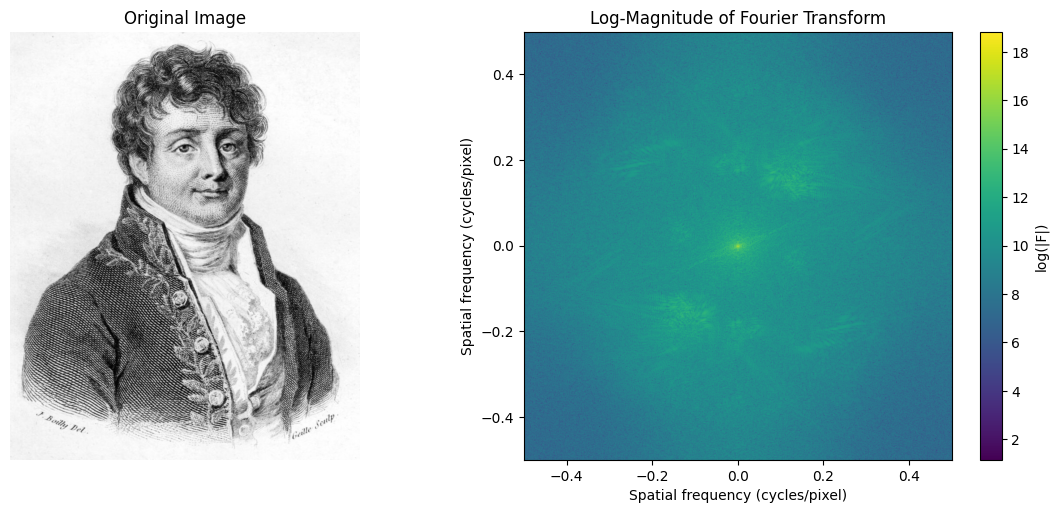

In [140]:
# Plot the original image and its magnitude spectrum
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_array, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(log_magnitude, cmap='viridis', extent=[fx.min(), fx.max(), fy.min(), fy.max()])
plt.title('Log‑Magnitude of Fourier Transform')
plt.xlabel('Spatial frequency (cycles/pixel)')
plt.ylabel('Spatial frequency (cycles/pixel)')
plt.colorbar(label='log(|F|)')

plt.tight_layout()
plt.show()

### Example 6 : Angular Spectrum Beam Propagation Method
in this example we will consider a two slits fourier transform and propagate it by the transfer function to d = 1m.

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [142]:
Nx = 2**11
Ny = 2**11
x0 = np.linspace(-0.02,0.02, Nx)
y0 = np.linspace(-0.02, 0.02, Ny)
X, Y = np.meshgrid(x0, y0)


U0 = np.zeros_like(X)
xc = 0.2e-3
width = 10e-6
lam = 632e-9
condition =  (np.abs(X - xc) < width) | (np.abs(X + xc) < width)
U0 = np.where(condition, 1, 0)

# plt.imshow(U0)

fx = np.fft.fftshift(np.fft.fftfreq(Nx, d= x0[1] - x0[0] ))   
fy = np.fft.fftshift(np.fft.fftfreq(Ny, d= y0[1] - y0[0]))

FX, FY = np.meshgrid(fx, fy)

In [143]:
d = 1
k = 2 * np.pi / lam
H = np.exp(1j * k * d) * np.exp(-1j * np.pi * lam * d * (FX**2 + FY**2))

# Propagate
U_fft = np.fft.fft2(U0)
U_prop_fft = U_fft * H
U_prop = np.fft.ifft2(U_prop_fft)

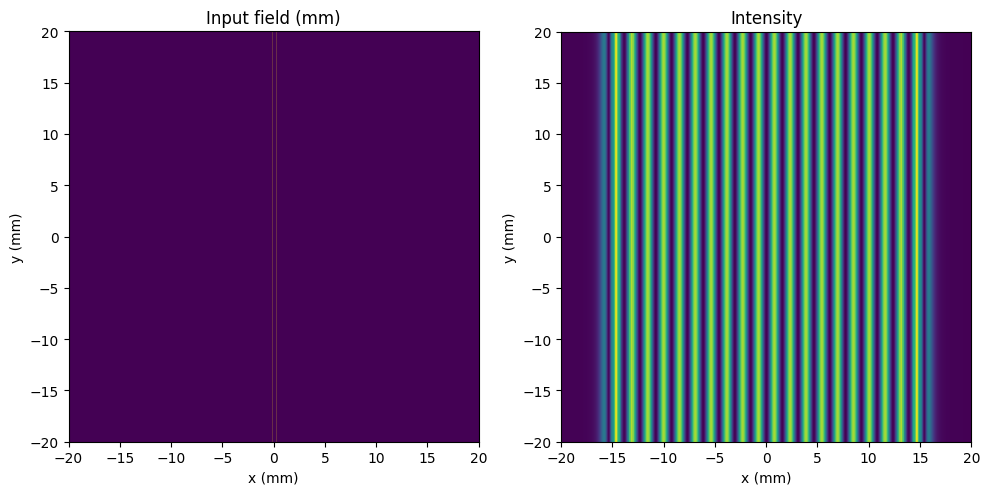

In [144]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(U0, extent=[x0[0]*1e3, x0[-1]*1e3, y0[0]*1e3, y0[-1]*1e3], cmap='viridis')
plt.title('Input field (mm)')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')

plt.subplot(1,2,2)
# The output plane has the same physical size as the input plane
plt.imshow(np.abs(U_prop)**2, extent=[x0[0]*1e3, x0[-1]*1e3, y0[0]*1e3, y0[-1]*1e3], cmap='viridis')
plt.title('Intensity')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')


plt.tight_layout()
plt.show()

### Example 7 : AS-BPM: (1 + 1)D Propagation -- Propagation in x-z plane: Spreading of a Gaussian beam

In [145]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [146]:
Nx = 1024
Nz = 128

x0 = np.linspace(-0.01, 0.01, Nx)      
z = np.linspace(0, 2.0, Nz)            

w0 = 100e-6                           
lam = 632.8e-9                         

dx = x0[1] - x0[0]
dz = z[1] - z[0]

U0 = np.exp(-(x0 / w0)**2)

# Spatial frequency axis
freq_x = np.fft.fftfreq(Nx, d=dx)

# Fresnel transfer function 
H = np.exp(-1j * np.pi * lam * dz * freq_x**2)


In [147]:
Hz = np.zeros((Nx, Nz), dtype=complex)
Hz[:, 0] = U0

for i in range(1, Nz):

    U_fft = np.fft.fft(Hz[:, i-1])

    U_prop_fft = U_fft * H

    Hz[:, i] = np.fft.ifft(U_prop_fft)
    
I = np.abs(Hz)**2
Ud = Hz[:, -1]

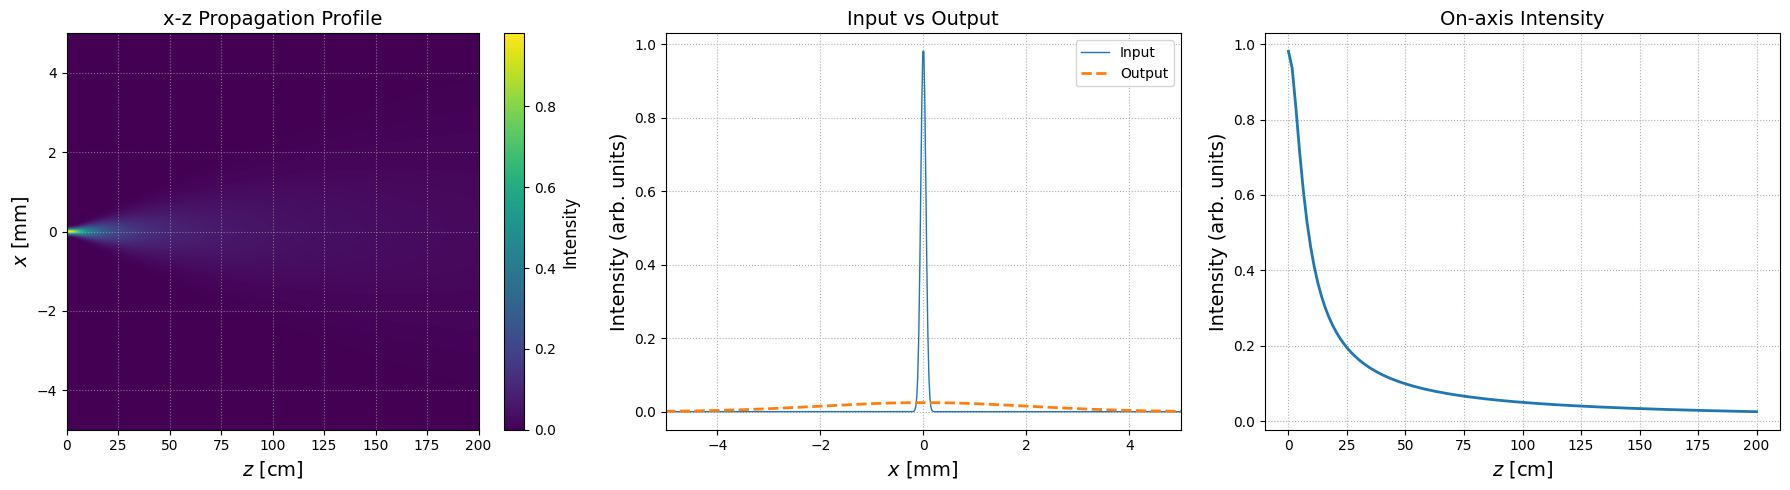

In [148]:
I_axial = I[Nx // 2, :]
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ----------------------------------------------------------------------
# Plot 1: x-z propagation 
# ----------------------------------------------------------------------
im = ax[0].imshow(I ,extent=[z[0]*100, z[-1]*100, x0[0]*1e3, x0[-1]*1e3],aspect='auto',cmap='viridis')

ax[0].set_ylim([-5, 5])
ax[0].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
ax[0].set_ylabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
ax[0].set_title('x-z Propagation Profile', fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.6)

cbar = fig.colorbar(im, ax=ax[0])
cbar.set_label('Intensity', fontsize=12)

# ----------------------------------------------------------------------
# Plot 2: Input vs Output intensity
# ----------------------------------------------------------------------
ax[1].plot(x0 * 1e3,np.abs(U0)**2,label='Input',linewidth=1)

ax[1].plot(x0 * 1e3,np.abs(Ud)**2,'--',label='Output',linewidth=2)

ax[1].set_xlim([-5, 5])
ax[1].set_xlabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
ax[1].set_ylabel('Intensity (arb. units)', fontsize=14)
ax[1].set_title('Input vs Output', fontsize=14)
ax[1].grid(True, linestyle=':')
ax[1].legend()

# ----------------------------------------------------------------------
# Plot 3: On-axis intensity
# ----------------------------------------------------------------------
ax[2].plot(z * 100, I_axial, linewidth=2)

ax[2].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
ax[2].set_ylabel('Intensity (arb. units)', fontsize=14)
ax[2].set_title('On-axis Intensity', fontsize=14)
ax[2].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

### Example 8 : AS-BPM: (1 + 1)D Propagation -- Propagation in x-z plane: Focusing a Gaussian beam

In [149]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [150]:
Nx = 1024
Nz = 1024

x0 = np.linspace(-0.01, 0.01, Nx)      
z = np.linspace(0, 2.0, Nz)            

f = 1
# w0 = 4e-3 
w0 = 2e-3                          
lam = 632.8e-9                         
k = 2*np.pi/lam

dx = x0[1] - x0[0]
dz = z[1] - z[0]

U0 = np.exp(-(x0 / w0)**2)


lens = np.exp(-1j * k * x0**2 / (2*f))
U0 = U0 * lens
# Spatial frequency axis
freq_x = np.fft.fftfreq(Nx, d=dx)

# Fresnel transfer function 
H = np.exp(-1j * np.pi * lam * dz * freq_x**2)


In [151]:
Hz = np.zeros((Nx, Nz), dtype=complex)
Hz[:, 0] = U0

for i in range(1, Nz):

    U_fft = np.fft.fft(Hz[:, i-1])

    U_prop_fft = U_fft * H

    Hz[:, i] = np.fft.ifft(U_prop_fft)
    
I = np.abs(Hz)**2
Ud = Hz[:, -1]

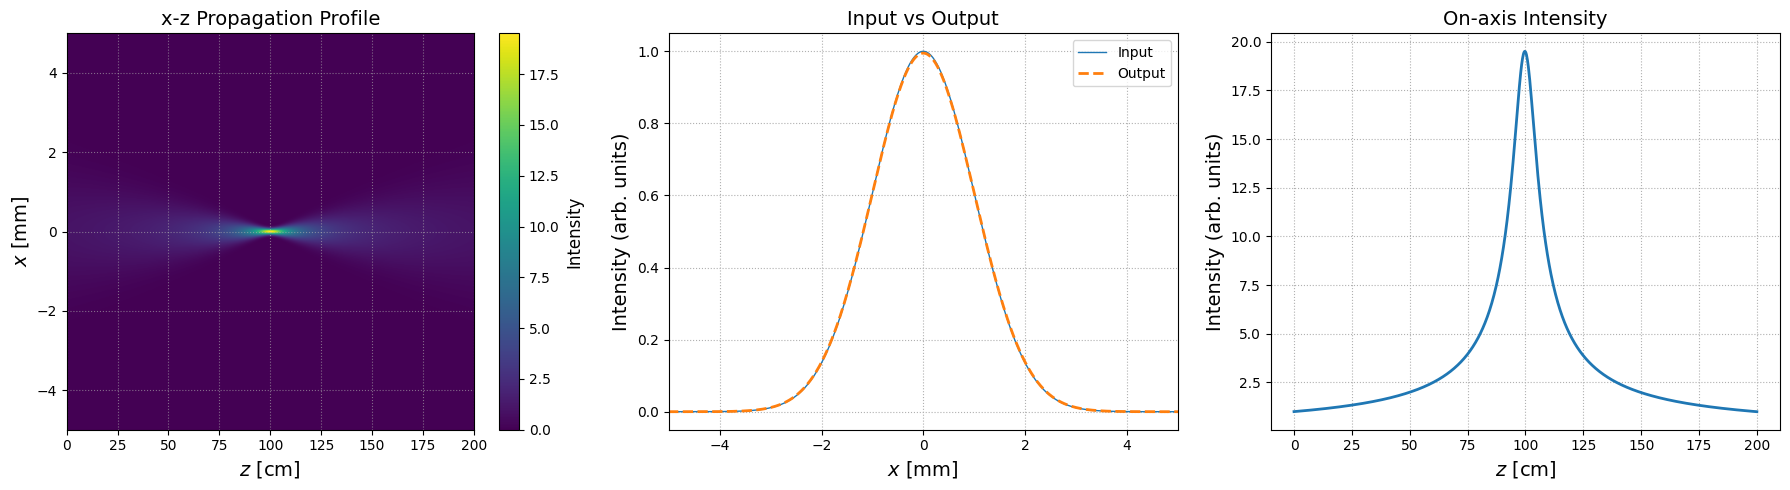

In [152]:
I_axial = I[Nx // 2, :]
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ----------------------------------------------------------------------
# Plot 1: x-z propagation 
# ----------------------------------------------------------------------
im = ax[0].imshow(I ,extent=[z[0]*100, z[-1]*100, x0[0]*1e3, x0[-1]*1e3],aspect='auto',cmap='viridis')

ax[0].set_ylim([-5, 5])
ax[0].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
ax[0].set_ylabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
ax[0].set_title('x-z Propagation Profile', fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.6)

cbar = fig.colorbar(im, ax=ax[0])
cbar.set_label('Intensity', fontsize=12)

# ----------------------------------------------------------------------
# Plot 2: Input vs Output intensity
# ----------------------------------------------------------------------
ax[1].plot(x0 * 1e3,np.abs(U0)**2,label='Input',linewidth=1)

ax[1].plot(x0 * 1e3,np.abs(Ud)**2,'--',label='Output',linewidth=2)

ax[1].set_xlim([-5, 5])
ax[1].set_xlabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
ax[1].set_ylabel('Intensity (arb. units)', fontsize=14)
ax[1].set_title('Input vs Output', fontsize=14)
ax[1].grid(True, linestyle=':')
ax[1].legend()

# ----------------------------------------------------------------------
# Plot 3: On-axis intensity
# ----------------------------------------------------------------------
ax[2].plot(z * 100, I_axial, linewidth=2)

ax[2].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
ax[2].set_ylabel('Intensity (arb. units)', fontsize=14)
ax[2].set_title('On-axis Intensity', fontsize=14)
ax[2].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

### Example 8 : AS-BPM: (1 + 1)D Propagation -- Two Beam Interference

In [153]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import pi

In [154]:
Nx = 1024
Nz = 1024

x0 = np.linspace(-0.01, 0.01, Nx)      
z = np.linspace(0, 2.0, Nz)            

f = 1
w0 = 1e-3                          
lam = 632.8e-9                         
k = 2*np.pi/lam
xc = 2e-3
th = 0.055
t = th * pi / 180
dx = x0[1] - x0[0]
dz = z[1] - z[0]


U1 = np.exp(-((x0 + xc)/w0)**2) * np.exp( 1j*k*x0*np.sin(t))
U2 = np.exp(-((x0 - xc)/w0)**2) * np.exp(-1j*k*x0*np.sin(t))

U0 = U1 + U2
# Spatial frequency axis
freq_x = np.fft.fftfreq(Nx, d=dx)

# Fresnel transfer function 
H = np.exp(-1j * np.pi * lam * dz * freq_x**2)


In [155]:
Hz = np.zeros((Nx, Nz), dtype=complex)
Hz[:, 0] = U0

for i in range(1, Nz):

    U_fft = np.fft.fft(Hz[:, i-1])

    U_prop_fft = U_fft * H

    Hz[:, i] = np.fft.ifft(U_prop_fft)
    
I = np.abs(Hz)**2
Ud = Hz[:, -1]

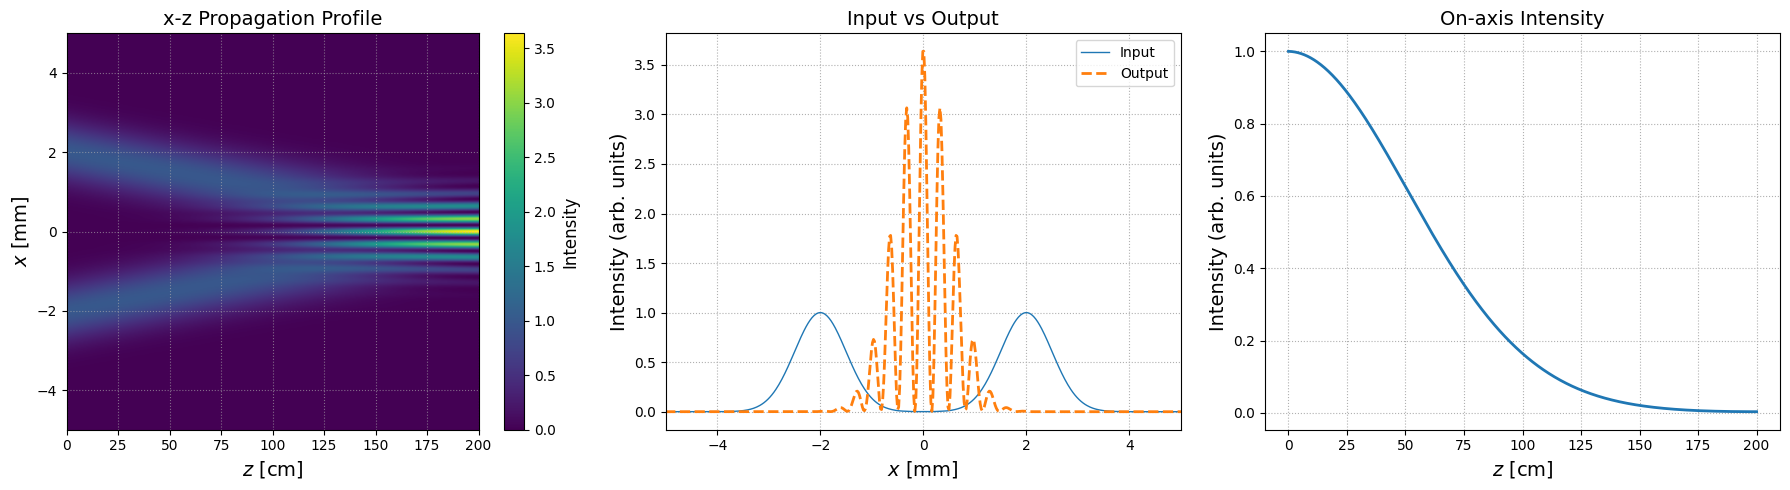

In [156]:
idx = np.argmin(np.abs(x0 - xc))
I_axial = I[idx,:]
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ----------------------------------------------------------------------
# Plot 1: x-z propagation 
# ----------------------------------------------------------------------
im = ax[0].imshow(I ,extent=[z[0]*100, z[-1]*100, x0[0]*1e3, x0[-1]*1e3],aspect='auto',cmap='viridis')

ax[0].set_ylim([-5, 5])
ax[0].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
ax[0].set_ylabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
ax[0].set_title('x-z Propagation Profile', fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.6)

cbar = fig.colorbar(im, ax=ax[0])
cbar.set_label('Intensity', fontsize=12)

# ----------------------------------------------------------------------
# Plot 2: Input vs Output intensity
# ----------------------------------------------------------------------
ax[1].plot(x0 * 1e3,np.abs(U0)**2,label='Input',linewidth=1)

ax[1].plot(x0 * 1e3,np.abs(Ud)**2,'--',label='Output',linewidth=2)

ax[1].set_xlim([-5, 5])
ax[1].set_xlabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
ax[1].set_ylabel('Intensity (arb. units)', fontsize=14)
ax[1].set_title('Input vs Output', fontsize=14)
ax[1].grid(True, linestyle=':')
ax[1].legend()

# ----------------------------------------------------------------------
# Plot 3: On-axis intensity
# ----------------------------------------------------------------------
ax[2].plot(z * 100, I_axial, linewidth=2)

ax[2].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
ax[2].set_ylabel('Intensity (arb. units)', fontsize=14)
ax[2].set_title('On-axis Intensity', fontsize=14)
ax[2].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

### Example 9 : AS-BPM: (1 + 1)D Propagation -- Diffraction from a Slit, Gratings(phase, amplitude)

In [157]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import pi

In [158]:
N = 1024
x0 = np.linspace(-0.01, 0.01, N)      # grid on x in m
z = np.linspace(0, 0.1, N)

dz = z[1] - z[0]
dx = x0[1] - x0[0]

lam = 632e-9                           # wavelength in m
k = 2*pi/lam

Lambda=50e-6                           # gamma in m
gamma = 2                               # phase modulation depth

w0=0.5e-3
width = 100e-6

Hz = np.zeros((N, N), dtype=complex)

def slit(X, width):
    condition = (0 < X) & (X < width)
    return np.where(condition, 1, 0)

def binary_amplitude_grating(X, Lambda):
    return (np.cos(2*np.pi*X/Lambda) >= 0).astype(float)

def sinusoidal_amplitude_grating(X, Lambda, m=1):
    return 1 + m*np.cos(2*np.pi*X/Lambda)

def binary_phase_grating(X,Lambda,gamma):
    return np.exp(
        1j*gamma*
        np.heaviside(np.cos(2*np.pi*X/Lambda),0)
    )
def sinusoidal_phase_grating(X,Lambda,gamma):
    phase = -gamma*0.5*(1+np.cos(2*np.pi*X/Lambda))
    return np.exp(1j*phase)
U0 = np.exp(-(x0/w0)**2)

slit_mask = slit(x0, width)
mask1 = binary_amplitude_grating(x0, Lambda)
mask2 = sinusoidal_amplitude_grating(x0, Lambda)
mask3 = binary_phase_grating(x0, Lambda, gamma)
mask4 = sinusoidal_phase_grating(x0, Lambda, gamma)
mask = [slit_mask, mask1, mask2, mask3, mask4]


freq_x = np.fft.fftfreq(N, d=dx)

H = np.exp(1j * np.pi * lam * dz * freq_x**2)

In [159]:
def plot():
    xc = 0                                   # on-axis position
    idx = np.argmin(np.abs(x0 - xc))
    I_axial = I[idx, :]

    fig, ax = plt.subplots(1, 2, figsize=(18, 5))

    # ------------------------------------------------------------------
    # Plot 1: x-z propagation
    # ------------------------------------------------------------------
    im = ax[0].imshow(I,extent=[z[0]*100, z[-1]*100, x0[0]*1e3, x0[-1]*1e3],aspect='auto',cmap='viridis')

    ax[0].set_ylim([-5, 5])
    ax[0].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
    ax[0].set_ylabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
    ax[0].set_title('x-z Propagation Profile', fontsize=14)
    ax[0].grid(True, linestyle=':', alpha=0.6)

    cbar = fig.colorbar(im, ax=ax[0])
    cbar.set_label('Intensity', fontsize=12)

    # ------------------------------------------------------------------
    # Plot 2: Input vs Output intensity
    # ------------------------------------------------------------------
    ax[1].plot(x0*1e3, np.abs(U0)**2,
               label='Input', linewidth=1)

    ax[1].plot(x0*1e3, np.abs(Ud)**2,
               '--', label='Output', linewidth=2)

    ax[1].set_xlim([-5, 5])
    ax[1].set_xlabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
    ax[1].set_ylabel('Intensity (arb. units)', fontsize=14)
    ax[1].set_title('Input vs Output', fontsize=14)
    ax[1].grid(True, linestyle=':')
    ax[1].legend()




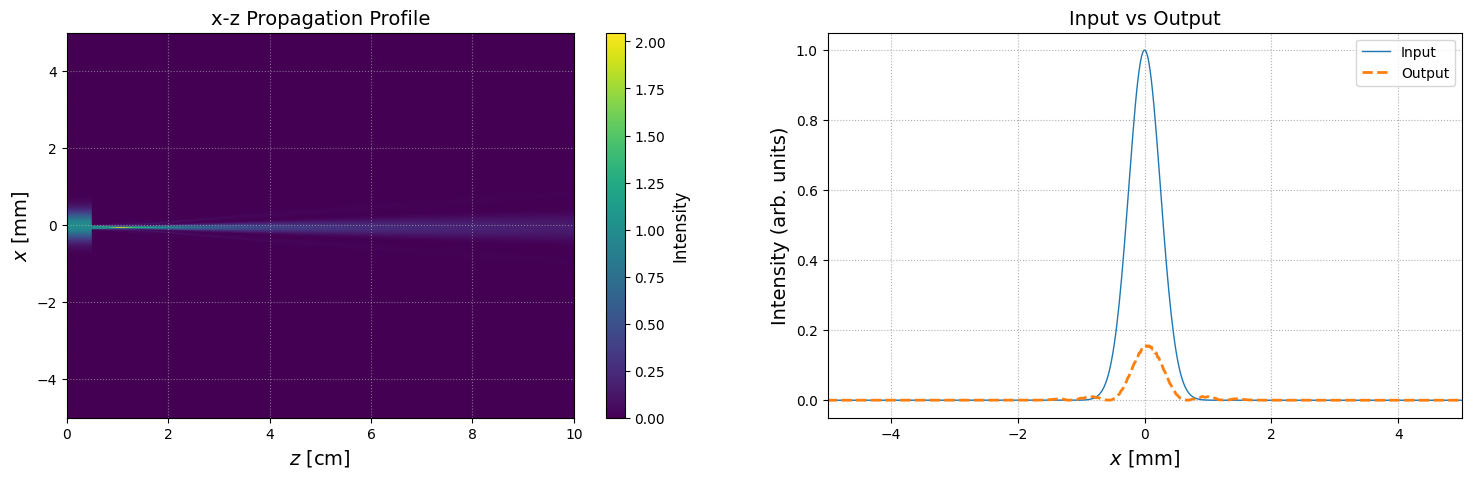

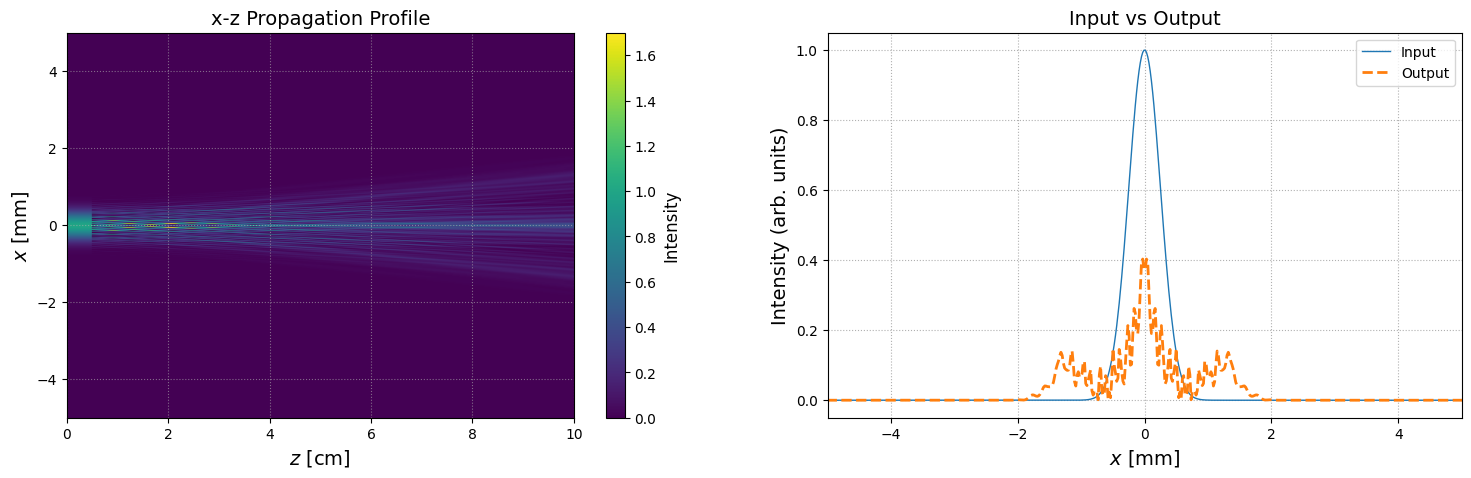

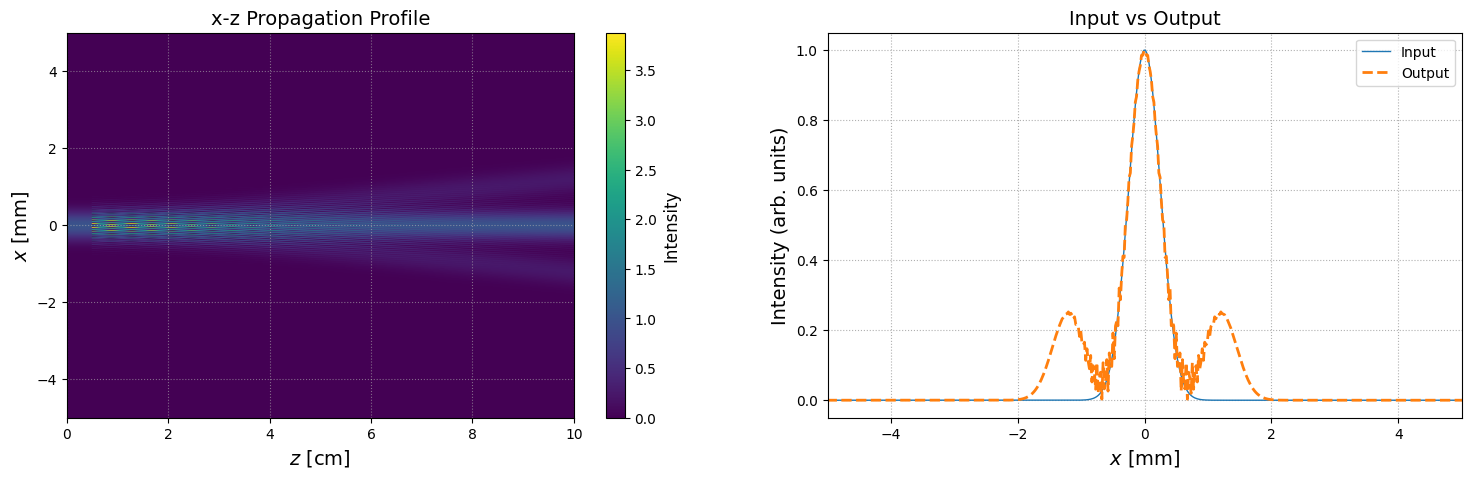

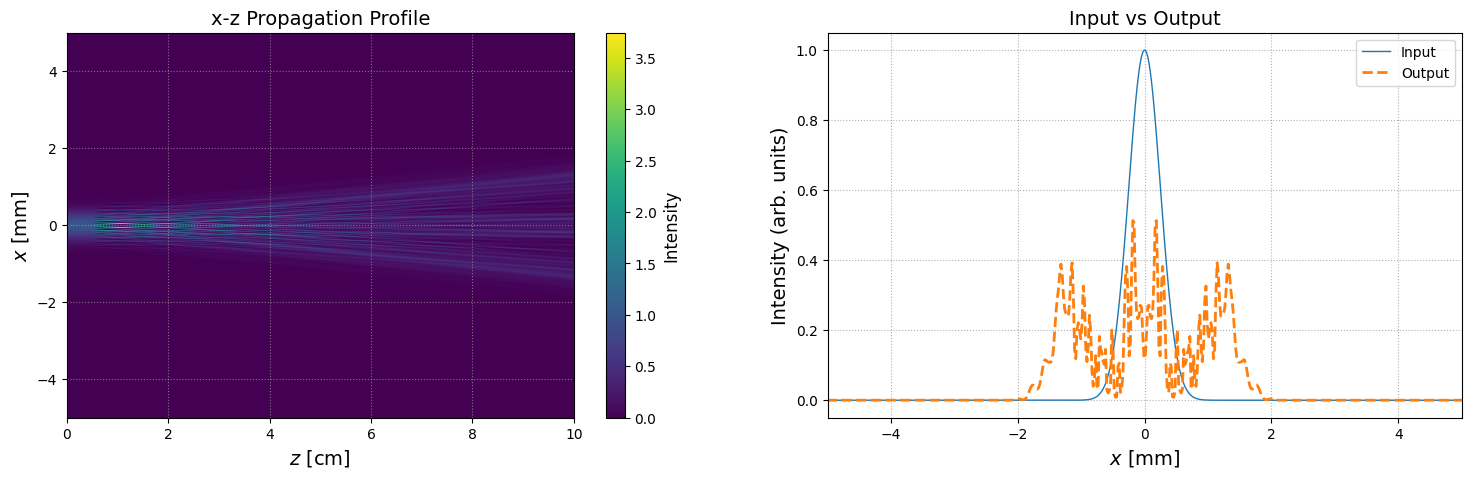

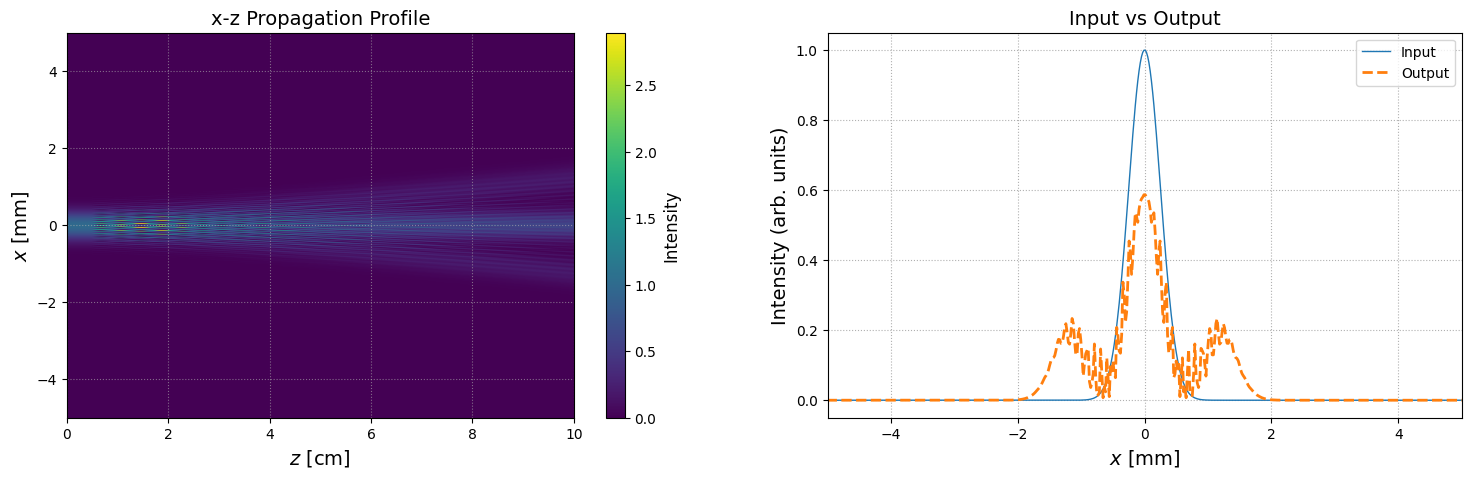

In [160]:
for ts in mask:

    Hz = np.zeros((N,N),dtype=complex)

    UT = U0.copy()

    Hz[:,0] = UT
    nz = 50

    for iz in range(1, N):

        if iz == nz:
            UT = UT * ts

        U_f = np.fft.fft(UT)

        U_f = U_f * H

        UT = np.fft.ifft(U_f)

        Hz[:, iz] = UT

    I = np.abs(Hz)**2
    Ud = Hz[:, -1]

    plot()

### Example 10 : (2+1)D Propagation: Spreading of a Gaussian/Bessel beam

In [161]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import pi
from scipy.special import j0

In [162]:
Nx = 1024
Ny = 1024
Nz = 128

x0 = np.linspace(-0.01, 0.01, Nx)
y0 = np.linspace(-0.01, 0.01, Nx)
z = np.linspace(0, 2, Nz)

X, Y = np.meshgrid(x0, y0)
r = np.sqrt(X**2 + Y**2)

dx = x0[1] - x0[0]
dy = y0[1] - y0[0]

wb=140e-6 # Width of the Bessel Beam
wa=3e-3
w0 = 200e-6

lam = 632.8e-9
k = 2* pi/ lam

freq_x = np.fft.fftfreq(Nx, dx)
freq_y = np.fft.fftfreq(Ny, dy)

FX, FY = np.meshgrid(freq_x, freq_y)

d = z[1] - z[0]
H = np.exp(1j * k * d) * np.exp(-1j * np.pi * lam * d * (FX**2 + FY**2))

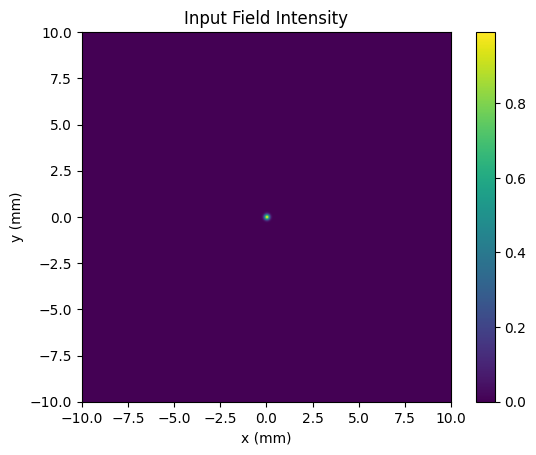

In [163]:

U0 = np.exp(-(r / w0 )**2) # Gaussian Beam (GB) at z=0 

# U0 = j0(r / wb)* np.exp(-(r / wa)**2)  # Bessel Beam (BB) at z=0
I = np.abs(U0**2)
plt.imshow(I, extent=[x0[0]*1000, x0[-1]*1000, y0[0]*1000, y0[-1]*1000])

plt.xlim([x0[0]*1000, x0[-1]*1000])
plt.ylim([y0[0]*1000, y0[-1]*1000])
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Input Field Intensity')
plt.colorbar()
plt.show()

In [164]:
# Propagation
Hz = np.zeros((Nx, Ny, Nz), dtype=np.complex128)
Hz[:,:,0] = U0
UT = U0.copy()
for iz in range(1, Nz):
    U_f = np.fft.fft2(UT)
    U_f = U_f * H
    UT = np.fft.ifft2(U_f)
    Hz[:,:,iz] = UT

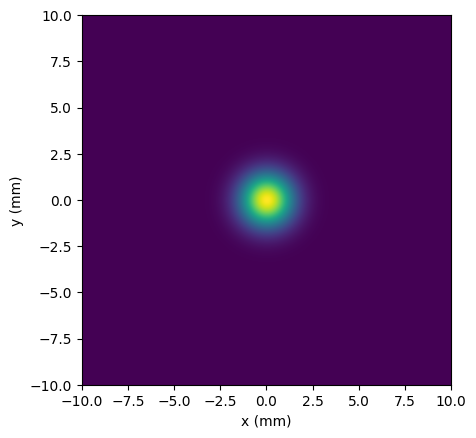

In [165]:
# Final intensity
I_final = np.abs(Hz[:,:,-1])**2
plt.imshow(I_final, extent=[x0[0]*1000, x0[-1]*1000, y0[0]*1000, y0[-1]*1000])
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.show()

### Example 11 : (2+1)D Propagation: Diffraction from a grating

In [166]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import pi
from scipy.special import j0

In [167]:
Nx = 1024
Ny = 1024
Nz = 128

x0 = np.linspace(-0.01, 0.01, Nx)
y0 = np.linspace(-0.01, 0.01, Nx)
z = np.linspace(0, 2, Nz)

X, Y = np.meshgrid(x0, y0)
r = np.sqrt(X**2 + Y**2)
t = np.arctan2(Y, X) 

dx = x0[1] - x0[0]
dy = y0[1] - y0[0]

wb=140e-6 # Width of the Bessel Beam
wa=3e-3
w0 = 200e-6

lam = 632.8e-9
k = 2* pi/ lam

freq_x = np.fft.fftfreq(Nx, dx)
freq_y = np.fft.fftfreq(Ny, dy)

FX, FY = np.meshgrid(freq_x, freq_y)

d = z[1] - z[0]
H = np.exp(1j * k * d) * np.exp(-1j * np.pi * lam * d * (FX**2 + FY**2))

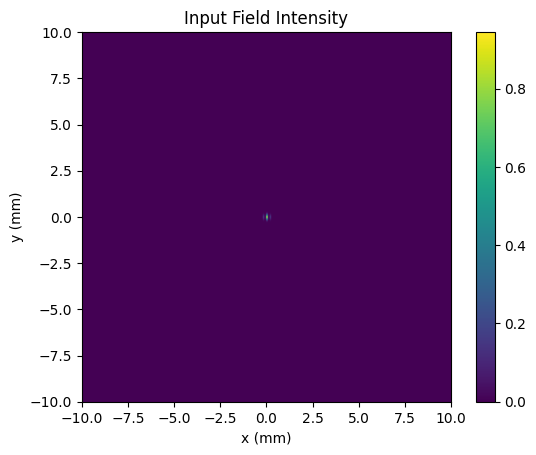

In [169]:

U0 = np.exp(-(r / w0 )**2) # Gaussian Beam (GB) at z=0 

L = 200e-6                                  # period [m]
tg = (1 + np.cos(2 * np.pi * X / L)) / 2
U0 = U0 * tg
I = np.abs(U0**2)
plt.imshow(I, extent=[x0[0]*1000, x0[-1]*1000, y0[0]*1000, y0[-1]*1000])

plt.xlim([x0[0]*1000, x0[-1]*1000])
plt.ylim([y0[0]*1000, y0[-1]*1000])
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Input Field Intensity')
plt.colorbar()
plt.show()

In [170]:
# Propagation
Hz = np.zeros((Nx, Ny, Nz), dtype=np.complex128)
Hz[:,:,0] = U0
UT = U0.copy()
for iz in range(1, Nz):
    U_f = np.fft.fft2(UT)
    U_f = U_f * H
    UT = np.fft.ifft2(U_f)
    Hz[:,:,iz] = UT

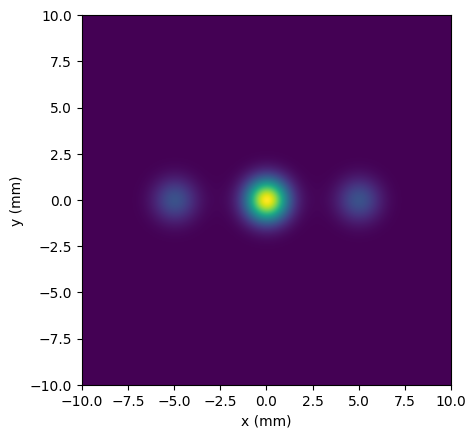

In [173]:
# Final intensity
I_final = np.abs(Hz[:,:,100])**2
plt.imshow(I_final, extent=[x0[0]*1000, x0[-1]*1000, y0[0]*1000, y0[-1]*1000])
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.show()

## 4.2 Propagation in Inhomogeneous Media & the Beam Propagation Method (BPM)



### 1. Inhomogeneous Media

In a standard (homogeneous) dielectric, the polarization $\mathbf{P}$ is proportional to the electric field $\mathbf{E}$ via the susceptibility $\chi$, and the displacement field is $\mathbf{D} = \epsilon \mathbf{E}$, with constant permittivity $\epsilon = \epsilon_0(1+\chi)$.

In an **inhomogeneous medium**, the properties vary with position:

$$
\chi = \chi(\mathbf{r}), \qquad 
\epsilon = \epsilon(\mathbf{r}), \qquad 
n = n(\mathbf{r})
$$

where $n(\mathbf{r}) = \sqrt{\epsilon(\mathbf{r})/\epsilon_0}$ is the local refractive index.  
Examples: graded‑index fibers, thermal lenses, atmospheric turbulence, or any medium with a spatially varying composition.

---

### 2. Wave Equation from Maxwell’s Equations

We start from Maxwell’s equations in a charge‑ and current‑free medium:

$$
\nabla \cdot \mathbf{D} = 0, \quad 
\nabla \cdot \mathbf{B} = 0, \quad 
\nabla \times \mathbf{E} = -\frac{\partial \mathbf{B}}{\partial t}, \quad 
\nabla \times \mathbf{H} = \frac{\partial \mathbf{D}}{\partial t}.
$$

With $\mathbf{B} = \mu_0 \mathbf{H}$ and $\mathbf{D} = \epsilon(\mathbf{r}) \mathbf{E}$, one can derive:

$$
\nabla \times (\nabla \times \mathbf{E}) = -\mu_0 \epsilon(\mathbf{r}) \frac{\partial^2 \mathbf{E}}{\partial t^2}.
$$

Using the vector identity $\nabla \times (\nabla \times \mathbf{E}) = \nabla(\nabla \cdot \mathbf{E}) - \nabla^2 \mathbf{E}$ and $\nabla \cdot (\epsilon \mathbf{E}) = 0$, we obtain:

$$
\nabla^2 \mathbf{E} + \nabla \left( \frac{1}{\epsilon} \nabla \epsilon \cdot \mathbf{E} \right) - \mu_0 \epsilon(\mathbf{r}) \frac{\partial^2 \mathbf{E}}{\partial t^2} = 0.
$$

This is the general wave equation for an inhomogeneous medium. The term $\nabla( \frac{1}{\epsilon} \nabla \epsilon \cdot \mathbf{E})$ couples the field components and makes analytical solutions difficult.

---

### 3. Slowly Varying Permittivity Approximation

If the refractive index changes **very little** over one optical wavelength, then $\frac{\nabla \epsilon}{\epsilon} \approx 0$, and the coupling term can be neglected:

$$
\nabla^2 \mathbf{E} - \mu_0 \epsilon(\mathbf{r}) \frac{\partial^2 \mathbf{E}}{\partial t^2} = 0.
$$

Even though $\epsilon$ still depends on $\mathbf{r}$, it is now treated as a **slowly varying** function. This is the starting point for most beam propagation models.

---

### 4. Paraxial Wave Equation

We assume the field propagates mainly along the $z$‑axis and write it as:

$$
U(x,y,z,t) = U_e(x,y,z) \exp\bigl[j(\omega t - k z)\bigr],
$$

where $U_e$ is the complex envelope, and $k = n_0 \omega / c$ with $n_0$ a reference refractive index. Substituting into the simplified wave equation and assuming the envelope varies slowly in $z$ (so that $\partial^2 U_e / \partial z^2$ can be neglected compared to $k \partial U_e / \partial z$), we obtain the **paraxial wave equation**:

$$
\nabla_{\perp}^2 U_e - 2jk \frac{\partial U_e}{\partial z} - \bigl[ k^2 - \mu_0 \epsilon(\mathbf{r}) \omega^2 \bigr] U_e = 0.
$$

Here $\nabla_{\perp}^2 = \partial^2/\partial x^2 + \partial^2/\partial y^2$ is the transverse Laplacian.

---

### 5. Relating to Refractive Index Variation

Write the local refractive index as $n(\mathbf{r}) = n_0 \bigl[1 + \Delta n(\mathbf{r})\bigr]$, where $\Delta n(\mathbf{r})$ is a **small** deviation ($|\Delta n| \ll 1$). Then:

$$
n(\mathbf{r})^2 \approx n_0^2 \bigl[1 + 2\Delta n(\mathbf{r})\bigr].
$$

Now compute the bracket term:

$$
k^2 - \mu_0 \epsilon(\mathbf{r}) \omega^2 = \frac{n_0^2 \omega^2}{c^2} - \frac{n(\mathbf{r})^2 \omega^2}{c^2}
= \frac{\omega^2}{c^2} \bigl[ n_0^2 - n(\mathbf{r})^2 \bigr] \approx -2k^2 \Delta n(\mathbf{r}),
$$

because $k = n_0 \omega / c$. Therefore, the paraxial equation becomes:

$$
\nabla_{\perp}^2 U_e - 2jk \frac{\partial U_e}{\partial z} + 2k^2 \Delta n(\mathbf{r}) U_e = 0.
$$

Rearranging:

$$
\boxed{\frac{\partial U_e}{\partial z} = \frac{1}{2jk} \nabla_{\perp}^2 U_e - jk \Delta n(\mathbf{r}) U_e}.
$$

This is the key equation for beam propagation in weakly inhomogeneous media.

---

### 6. Operator Form & Split‑Step Idea

We can write the equation as:

$$
\frac{\partial U_e}{\partial z} = (\hat{D} + \hat{S}) U_e,
$$

where  

- **Diffraction operator**: $\displaystyle \hat{D} = \frac{1}{2jk} \nabla_{\perp}^2$  
- **Inhomogeneity (phase) operator**: $\displaystyle \hat{S} = -j k \Delta n(\mathbf{r})$

Formally, over a small step $\Delta z$, the solution is:

$$
U_e(z+\Delta z) = \exp\bigl[ (\hat{D}+\hat{S}) \Delta z \bigr] U_e(z).
$$

Because $\hat{D}$ and $\hat{S}$ do not commute, we approximate the exponential using a **split‑step**:

$$
\exp\bigl[(\hat{D}+\hat{S})\Delta z\bigr] \approx \exp(\hat{D}\Delta z)\,\exp(\hat{S}\Delta z).
$$

This is accurate to first order in $\Delta z$ (second‑order symmetric splitting is also possible).

---

### 7. Numerical Implementation (Split‑Step BPM)

We apply the operators sequentially in a way that exploits Fourier transforms:

1. **Start** with the envelope $U_e(x,y;z)$.

2. **Apply diffraction in $k$‑space** – because $\hat{D}$ is diagonal in the spatial frequency domain.  
   Compute:
   $$
   \tilde{U}_e(k_x,k_y;z) = \mathcal{F}\{U_e(x,y;z)\}
   $$
   then
   $$
   \tilde{U}_e(k_x,k_y;z+\Delta z) = \tilde{U}_e(k_x,k_y;z) \exp\left[ j\Delta z \frac{k_x^2+k_y^2}{2k} \right].
   $$
   Here $\mathcal{F}$ denotes the 2D Fourier transform.

3. **Transform back** to real space:
   $$
   U_e'(x,y;z+\Delta z) = \mathcal{F}^{-1}\bigl\{ \tilde{U}_e(k_x,k_y;z+\Delta z) \bigr\}.
   $$

4. **Apply the inhomogeneity operator** (pure phase factor in real space):
   $$
   U_e(x,y;z+\Delta z) = U_e'(x,y;z+\Delta z) \; \exp\bigl( \hat{S} \Delta z \bigr)
   = U_e'(x,y;z+\Delta z) \; \exp\bigl( -j k \Delta n(x,y,z) \Delta z \bigr).
   $$

The result is the field envelope at $z+\Delta z$. The process is repeated for each propagation step.

---

### 8. Why This Method Is Powerful

- The split‑step Fourier BPM is **pseudo‑spectral** – it uses FFTs to handle diffraction exactly (for homogeneous steps) and local phase corrections for the inhomogeneity.
- It is very efficient, because FFT algorithms scale as $O(N \log N)$ per step.
- The same structure appears in **nonlinear optics** (Kerr effect), where $\Delta n$ depends on the field intensity: $\Delta n = n_2 |U_e|^2$. Then the equation becomes nonlinear, but the split‑step method still works – it becomes the **split‑step Fourier method** for the nonlinear Schrödinger equation.

---

### 9. Summary

| **Step** | **Action** |
|----------|-------------|
| 1 | Start with $U_e(x,y;z)$ |
| 2 | Fourier transform → $\tilde{U}_e(k_x,k_y;z)$ |
| 3 | Multiply by diffraction propagator $\exp\left(j\Delta z \frac{k_x^2+k_y^2}{2k}\right)$ |
| 4 | Inverse Fourier transform → $U_e'(x,y;z+\Delta z)$ |
| 5 | Multiply by phase factor $\exp(-j k \Delta n \Delta z)$ → $U_e(x,y;z+\Delta z)$ |
| 6 | Repeat for next $z$‑step |

This algorithm is the backbone of many photonic design tools (simulating fibers, couplers, gratings, and Kerr media).

> Reference: D. Marcuse, *Light Transmission Optics*, Van Nostrand, 1982 (Chap. 1).

## Problems

### Problem 1 : Diffraction Pattern

#### 1. Circular Aperture

Modify the propagation code to find the diffraction pattern of a circular aperture of diameter $D$ at a distance $d$ from the plane of the aperture


#### 2. Rectangular Aperture

Perform a similar analysis for a rectangular aperture. 



In [174]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import pi

In [175]:
Nx = 1024
Ny = 512

x0 = np.linspace(-1, 1, Nx)  # mm
y0 = np.linspace(-1, 1, Ny)  # mm

dx = x0[1] - x0[0]
dy = y0[1] - y0[0]
radius=0.03
X, Y = np.meshgrid(x0, y0)

#### converting coordinates into polar in case of circular aperture
def car2pol(X, Y):
    r = np.sqrt(X**2 + Y**2)
    th = np.arctan2(Y, X)
    return r, th

r, th = car2pol(X, Y)


def square_aperture(X, Y, half_width=0.05):
    condition = (np.abs(X) < half_width) & (np.abs(Y) < 1.5 * half_width)
    return np.where(condition, 1.0, 0.0)

def circular(r, radius=0.03):
    condition = r < radius
    return np.where(condition, 1.0, 0.0)

# --- Generate the apertures ---
# U0 = square_aperture(X, Y)
# U0_txt = "square_aperture"

U0 = circular(r,radius)
U0_txt = "circular_aperture"



lam =  0.0006328
d = 20 # in mm
          
k = 2 * np.pi / lam
freq_x = np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))
freq_y = np.fft.fftshift(np.fft.fftfreq(Ny, d=dy))

FX, FY = np.meshgrid(freq_x, freq_y)

In [176]:
# Propagate
H = np.exp(1j * np.pi * lam * d * (FX**2 + FY**2))
U_fft = np.fft.fftshift(np.fft.fft2(U0))

U_prop_fft = U_fft * H

U_prop = np.fft.ifft2(np.fft.ifftshift(U_prop_fft))
I = np.abs(U_prop)**2
I /= I.max()

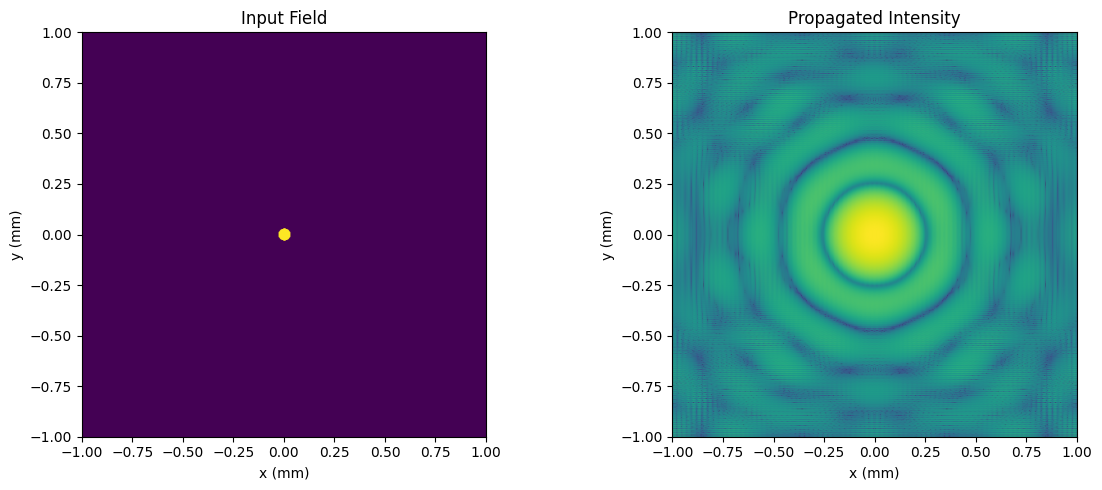

In [177]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax[0].imshow(U0,extent=[x0.min(), x0.max(), y0.min(), y0.max()],cmap='viridis')

ax[0].set_title('Input Field')
ax[0].set_xlabel('x (mm)')
ax[0].set_ylabel('y (mm)')

im2 = ax[1].imshow(np.log10(I + 1e-6),extent=[x0.min(), x0.max(), y0.min(), y0.max()],cmap='viridis')
ax[1].set_title('Propagated Intensity')
ax[1].set_xlabel('x (mm)')
ax[1].set_ylabel('y (mm)')

plt.tight_layout()
plt.show()



### Problem 2 :  Parseval's Theorem Verification

Through numerical investigation, show that the Parseval equation holds for each of the calculated Fourier pairs.

**Parseval's Theorem:**  
The signal energy, which is the integral of the signal power $|f(t)|^2$, equals the integral of the energy spectral density $|F(\nu)|^2$, so that

$$
\int_{-\infty}^{\infty} |f(t)|^2 \, dt = \int_{-\infty}^{\infty} |F(\nu)|^2 \, d\nu.
$$

(A.1-7) Parseval’s Theorem

In [178]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import pi

In [179]:
N = 1024
x0 = np.linspace(-1, 1, N)
w0 = 0.2
Gx = np.exp(-(x0 / w0)**2)   
Sum_Gx = np.sum(np.abs(Gx)**2)
# plt.plot(x0,Gx)

In [180]:
Sum_gx =  np.sum(np.abs(Gx)**2)
# DFT 
Gx_fft = np.fft.fft(Gx)        
energy_freq = np.sum(np.abs(Gx_fft)**2) 

print(f"Energy in space domain: {Sum_Gx:.6f}")
print(f"Energy in frequency domain: {Sum_gx:.6f}")
print(f"Difference: {np.abs(Sum_Gx - Sum_gx):.2e}")

Energy in space domain: 128.214036
Energy in frequency domain: 128.214036
Difference: 0.00e+00


### Problem 3:  Comparison of Numerical and Analytical Gaussian Beam Propagation

##### Compare the results of the numerical and analytical propagation of a Gaussian beam in terms of:

##### 1. Beam Width \(w(z)\)
##### 2. Axial (On-Axis) Intensity Profile \(I(0,z)\)
##### 3. Rayleigh Length \(z_R\)

In [181]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import pi

In [182]:
Nx = 1024
Nz = 128

x0 = np.linspace(-0.01, 0.01, Nx)      
z = np.linspace(0, 2.0, Nz)            

w0 = 500e-6                           
lam = 632.8e-9                         

dx = x0[1] - x0[0]
dz = z[1] - z[0]

U0 = np.exp(-(x0 / w0)**2)

# Spatial frequency axis
freq_x = np.fft.fftfreq(Nx, d=dx)

# Fresnel transfer function 
H = np.exp(-1j * np.pi * lam * dz * freq_x**2)


In [183]:

def FWHM(Gx, x, threshold_ratio=0.5, out_val=20):
    max_val = np.max(Gx)
    threshold = max_val * threshold_ratio
    condition = Gx > threshold
    new_arr = np.where(condition, out_val, Gx)
    
    indices_out = np.where(new_arr == out_val)[0]
    # if len(indices_out) < 2:
    #     return np.nan  
    # plt.plot(x, new_arr)
    idx_left = indices_out[0]
    idx_right = indices_out[-1]
    width = x[idx_right] - x[idx_left]
    return width

In [184]:
def propagation_analytical(x, z, w0, lam, I0=1):
    # Rayleigh length
    z_R = np.pi * w0**2 / lam
    w_z = w0 * np.sqrt(1 + (z / z_R)**2)
    I_axial = I0 / (1 + (z / z_R)**2)
    return {
            'z_R': z_R,
            'w_z': w_z,
            'I_axial': I_axial
        }

In [185]:
Hz = np.zeros((Nx,Nz), dtype=complex)

Hz[:, 0] = U0

for i in range(1, Nz):

    U_fft = np.fft.fft(Hz[:, i-1])

    U_prop_fft = U_fft * H

    Hz[:, i] = np.fft.ifft(U_prop_fft)
    
I = np.abs(Hz)**2
Ud = Hz[:, -1]



In [186]:
ana = propagation_analytical(x0, z, w0, lam)

z_R_analytical = ana['z_R']
w_analytical = ana['w_z']
I_analytical = ana['I_axial']

# Numerical beam width (FWHM)
beam_width_num = np.zeros(Nz)

for k in range(Nz):
    beam_width_num[k] = FWHM(I[:, k], x0)

# Convert FWHM -> Gaussian beam radius
w_num = beam_width_num / np.sqrt(2*np.log(2))


# Numerical on-axis intensity
I_axial_num = I[Nx//2, :]

I_axial_num = I_axial_num / np.max(I_axial_num)
I_analytical = I_analytical / np.max(I_analytical)


# Numerical Rayleigh length
# w(zR) = sqrt(2)*w0
target_width = np.sqrt(2) * w_num[0]

idx_zR = np.argmin(np.abs(w_num - target_width))

z_R_numerical = z[idx_zR]

print(f'Analytical Rayleigh Length = {z_R_analytical:.4f} m')
print(f'Numerical Rayleigh Length  = {z_R_numerical:.4f} m')
print(f'Error (%) = {100*abs(z_R_numerical-z_R_analytical)/z_R_analytical:.2f}')

Analytical Rayleigh Length = 1.2411 m
Numerical Rayleigh Length  = 1.1496 m
Error (%) = 7.38


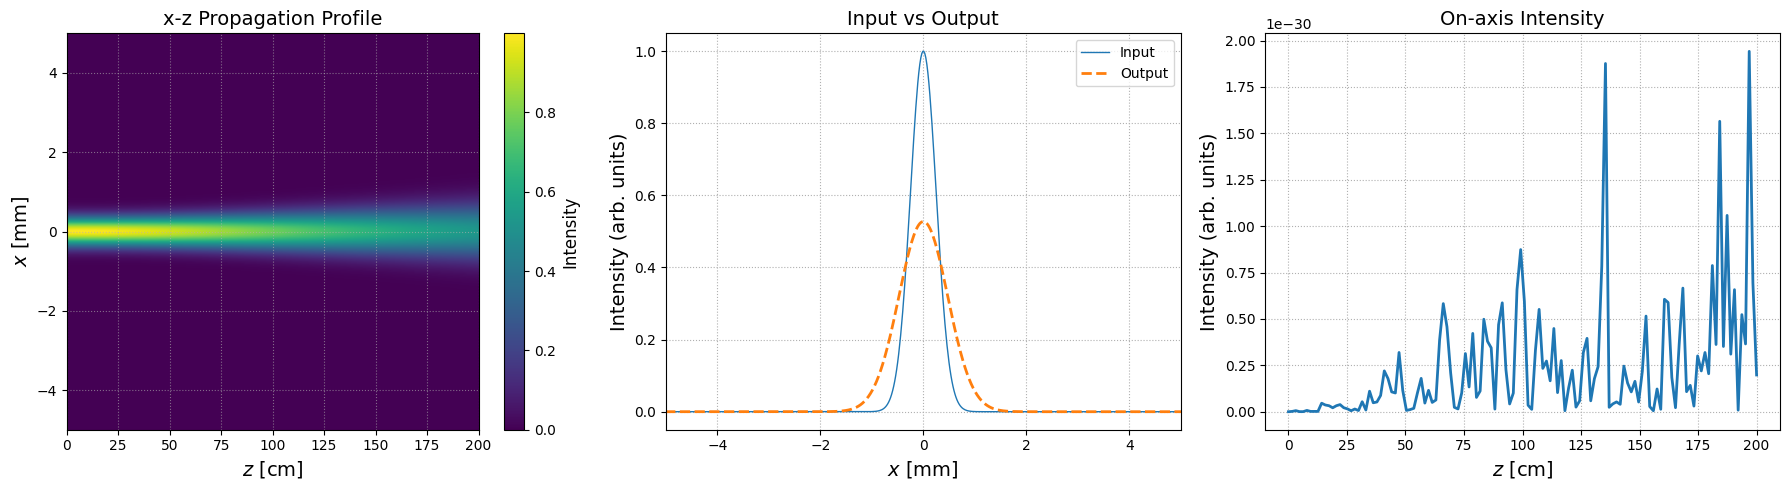

In [187]:
I_axial = I[Nz // 2, :]
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ----------------------------------------------------------------------
# Plot 1: x-z propagation 
# ----------------------------------------------------------------------
im = ax[0].imshow(I ,extent=[z[0]*100, z[-1]*100, x0[0]*1e3, x0[-1]*1e3],aspect='auto',cmap='viridis')

ax[0].set_ylim([-5, 5])
ax[0].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
ax[0].set_ylabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
ax[0].set_title('x-z Propagation Profile', fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.6)

cbar = fig.colorbar(im, ax=ax[0])
cbar.set_label('Intensity', fontsize=12)

# ----------------------------------------------------------------------
# Plot 2: Input vs Output intensity
# ----------------------------------------------------------------------
ax[1].plot(x0 * 1e3,np.abs(U0)**2,label='Input',linewidth=1)

ax[1].plot(x0 * 1e3,np.abs(Ud)**2,'--',label='Output',linewidth=2)

ax[1].set_xlim([-5, 5])
ax[1].set_xlabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
ax[1].set_ylabel('Intensity (arb. units)', fontsize=14)
ax[1].set_title('Input vs Output', fontsize=14)
ax[1].grid(True, linestyle=':')
ax[1].legend()

# ----------------------------------------------------------------------
# Plot 3: On-axis intensity
# ----------------------------------------------------------------------
ax[2].plot(z * 100, I_axial, linewidth=2)

ax[2].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
ax[2].set_ylabel('Intensity (arb. units)', fontsize=14)
ax[2].set_title('On-axis Intensity', fontsize=14)
ax[2].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

### Problem 4 : Implement a beam expander in the propagation code in a way that it doubles the width of an input Gaussian beam.

In [188]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import pi

In [189]:
Nx = 1024
Nz = 128

x0 = np.linspace(-0.025, 0.025, Nx)      
z = np.linspace(0, 2, Nz)            

w0 = 500e-6                           
lam = 632.8e-9                         
k = 2*pi/lam
dx = x0[1] - x0[0]
dz = z[1] - z[0]
f1 = -4
f2 = 0.1

U0 = np.exp(-(x0 / w0)**2)

# Spatial frequency axis
freq_x = np.fft.fftfreq(Nx, d=dx)

# Fresnel transfer function 
H = np.exp(-1j * np.pi * lam * dz * freq_x**2)


# Lens function
def Lens(k, f, x):
    return np.exp(-1J*k*(x**2/2*f))


In [190]:

Hz = np.zeros((Nx,Nz),dtype=complex)

UT = U0.copy()

Hz[:,0] = UT
nz = 30
nz2 = 60
for iz in range(1, Nz):

    if iz == nz:
        UT = UT * Lens(k,f1,x0)
    elif iz == nz2:
        UT = UT * Lens(k,f2,x0)
    U_f = np.fft.fft(UT)

    U_f = U_f * H

    UT = np.fft.ifft(U_f)

    Hz[:, iz] = UT

I = np.abs(Hz)**2
Ud = Hz[:, -1]



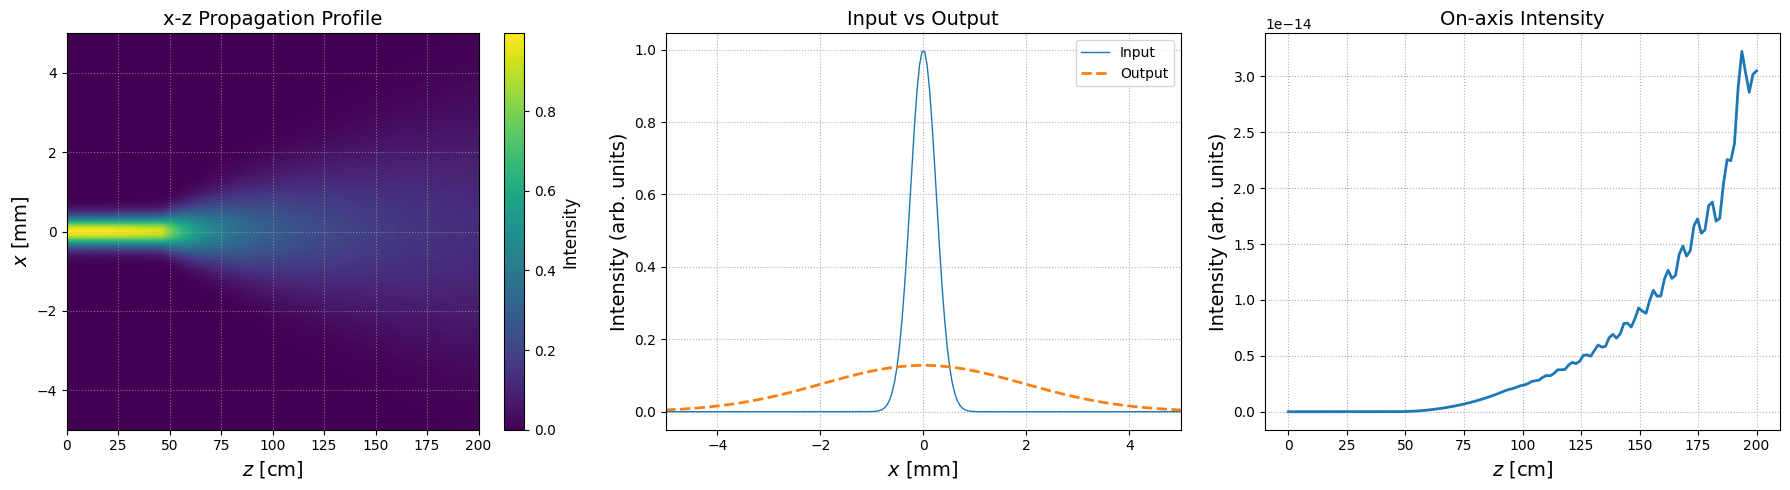

In [191]:
I_axial = I[Nz // 2, :]
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ----------------------------------------------------------------------
# Plot 1: x-z propagation 
# ----------------------------------------------------------------------
im = ax[0].imshow(I ,extent=[z[0]*100, z[-1]*100, x0[0]*1e3, x0[-1]*1e3],aspect='auto',cmap='viridis')

ax[0].set_ylim([-5, 5])
ax[0].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
ax[0].set_ylabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
ax[0].set_title('x-z Propagation Profile', fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.6)

cbar = fig.colorbar(im, ax=ax[0])
cbar.set_label('Intensity', fontsize=12)

# ----------------------------------------------------------------------
# Plot 2: Input vs Output intensity
# ----------------------------------------------------------------------
ax[1].plot(x0 * 1e3,np.abs(U0)**2,label='Input',linewidth=1)

ax[1].plot(x0 * 1e3,np.abs(Ud)**2,'--',label='Output',linewidth=2)

ax[1].set_xlim([-5, 5])
ax[1].set_xlabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
ax[1].set_ylabel('Intensity (arb. units)', fontsize=14)
ax[1].set_title('Input vs Output', fontsize=14)
ax[1].grid(True, linestyle=':')
ax[1].legend()

# ----------------------------------------------------------------------
# Plot 3: On-axis intensity
# ----------------------------------------------------------------------
ax[2].plot(z * 100, I_axial, linewidth=2)

ax[2].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
ax[2].set_ylabel('Intensity (arb. units)', fontsize=14)
ax[2].set_title('On-axis Intensity', fontsize=14)
ax[2].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

### Problem 5 : Implement a double slit aperture in the propagation code and investigate the diffraction pattern as a function of the slit width and inter-slit distance.

In [192]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import pi

In [193]:
Nx = 1024
Nz = 128
x0 = np.linspace(-0.01, 0.01, Nx)
z = np.linspace(0, 2, Nz)

dx = x0[1] - x0[0]
dz = z[1] - z[0]
width = 6e-4
w0 = 1e-3
lam = 632.8e-9
k = 2* pi/ lam

U0 = np.exp(-(x0/w0)**2)

freq_x = np.fft.fftfreq(Nx, d=dx)

# Fresnel transfer function 
H = np.exp(-1j * np.pi * lam * dz * freq_x**2)

# slit parameters
a = 100e-6
xc = 0.4e-3

ts = (
    (np.abs(x0-xc) < a/2) |
    (np.abs(x0+xc) < a/2)
).astype(float)

# plt.figure()
# plt.plot(x0*1e3, ts)
# plt.xlabel('x [mm]')
# plt.ylabel('Transmission')
# plt.title('Double Slit Aperture')
# plt.grid(True)
# plt.show()

In [194]:

Hz = np.zeros((Nx,Nz),dtype=complex)

UT = U0.copy()

Hz[:,0] = UT
nz = 10
for iz in range(1, Nz):

    if iz == nz:
        UT = UT * ts

    U_f = np.fft.fft(UT)

    U_f = U_f * H

    UT = np.fft.ifft(U_f)

    Hz[:, iz] = UT

I = np.abs(Hz)**2
Ud = Hz[:, -1]



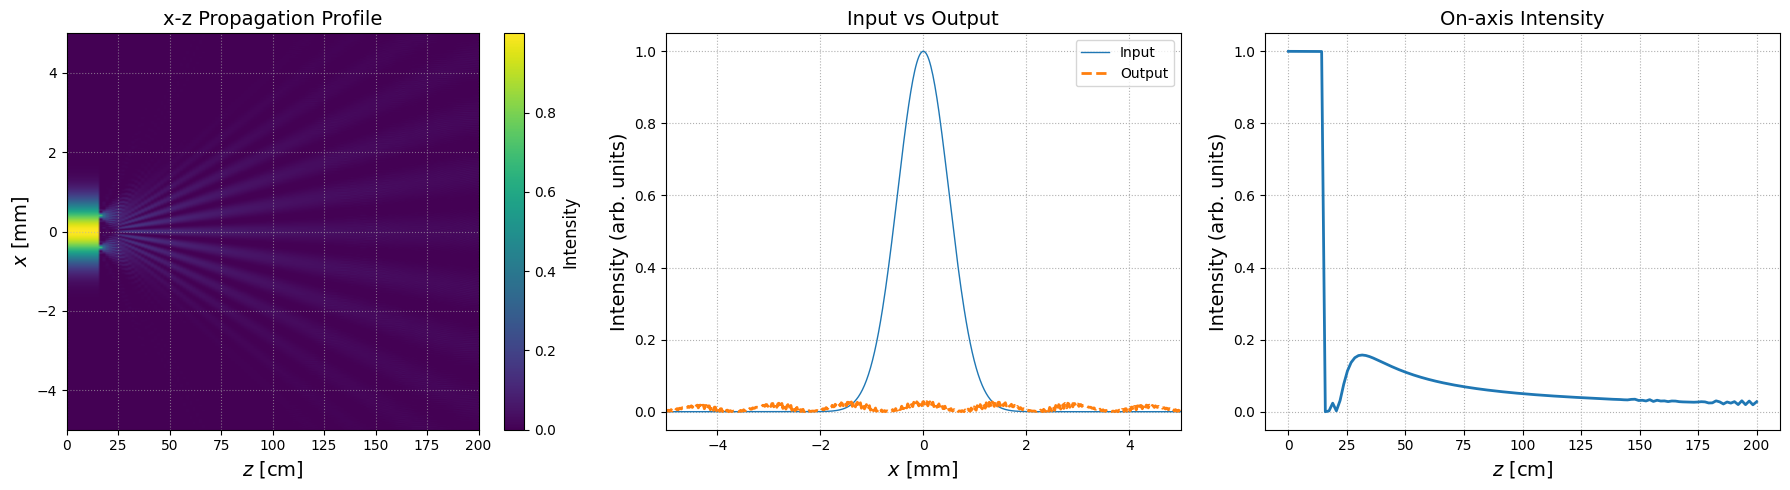

In [195]:
I_axial = I[Nx//2, :]
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ----------------------------------------------------------------------
# Plot 1: x-z propagation 
# ----------------------------------------------------------------------
im = ax[0].imshow(I ,extent=[z[0]*100, z[-1]*100, x0[0]*1e3, x0[-1]*1e3],aspect='auto',cmap='viridis')

ax[0].set_ylim([-5, 5])
ax[0].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
ax[0].set_ylabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
ax[0].set_title('x-z Propagation Profile', fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.6)

cbar = fig.colorbar(im, ax=ax[0])
cbar.set_label('Intensity', fontsize=12)

# ----------------------------------------------------------------------
# Plot 2: Input vs Output intensity
# ----------------------------------------------------------------------
ax[1].plot(x0 * 1e3,np.abs(U0)**2,label='Input',linewidth=1)

ax[1].plot(x0 * 1e3,np.abs(Ud)**2,'--',label='Output',linewidth=2)

ax[1].set_xlim([-5, 5])
ax[1].set_xlabel(r'$x\ \mathrm{[mm]}$', fontsize=14)
ax[1].set_ylabel('Intensity (arb. units)', fontsize=14)
ax[1].set_title('Input vs Output', fontsize=14)
ax[1].grid(True, linestyle=':')
ax[1].legend()

# ----------------------------------------------------------------------
# Plot 3: On-axis intensity
# ----------------------------------------------------------------------
ax[2].plot(z * 100, I_axial, linewidth=2)

ax[2].set_xlabel(r'$z\ \mathrm{[cm]}$', fontsize=14)
ax[2].set_ylabel('Intensity (arb. units)', fontsize=14)
ax[2].set_title('On-axis Intensity', fontsize=14)
ax[2].grid(True, linestyle=':')

plt.tight_layout()
plt.show()